# 🔍 Deteksi Penipuan Transaksi Kartu Kredit
## Project Akhir Semester — Teori Kecerdasan Buatan

**Teknik yang Digunakan:**
- SMOTE (Synthetic Minority Over-sampling Technique)
- Genetic Algorithm (Seleksi Fitur)
- 3 Model Klasifikasi: Decision Tree, Random Forest, SVM

**Struktur Notebook:**
1. Setup & Instalasi
2. Load & Eksplorasi Dataset (EDA)
3. Preprocessing
4. 12 Eksperimen (3 model × 4 kondisi)
5. Visualisasi & Perbandingan
6. Simpan Model Terbaik

> **Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
> Download `creditcard.csv` lalu upload ke Colab atau mount Google Drive.


## 1. Setup & Instalasi

In [2]:
# Install library yang dibutuhkan
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib -q

import warnings
warnings.filterwarnings('ignore')
print("✅ Semua library berhasil diinstall")


✅ Semua library berhasil diinstall


In [3]:
# Import semua library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import time
import random
from collections import Counter

# Preprocessing & Model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline

# SMOTE
from imblearn.over_sampling import SMOTE

# Style plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")
PALETTE = {"Decision Tree": "#378ADD", "Random Forest": "#0F6E56", "SVM": "#D85A30"}

print("✅ Semua import berhasil")
print(f"   Numpy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")

✅ Semua import berhasil
   Numpy  : 2.0.2
   Pandas : 2.2.2


## 2. Load & Eksplorasi Dataset (EDA)

### Cara mendapatkan dataset:
1. Download dari [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
2. Upload file `creditcard.csv` ke Google Colab, **atau**
3. Mount Google Drive jika file sudah ada di sana


In [4]:
# ── Pilih salah satu cara load data ──────────────────────

# CARA 1: Upload langsung ke Colab
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('creditcard.csv')

# CARA 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

# CARA 3: Load dari path lokal (jika sudah ada)
# df = pd.read_csv('creditcard.csv')

print(f"✅ Dataset berhasil dimuat")
print(f"   Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"   Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Mounted at /content/drive
✅ Dataset berhasil dimuat
   Shape  : 284,807 baris × 31 kolom
   Memory : 70.6 MB


In [5]:
# Tampilkan 5 baris pertama
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Informasi dasar dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(df.info())
print()
print("Missing values:", df.isnull().sum().sum())
print("Duplikat      :", df.duplicated().sum())


INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float

DISTRIBUSI KELAS
Normal (0) : 284,315 transaksi (99.83%)
Fraud  (1) : 492 transaksi (0.1727%)
Rasio      : 1 fraud per 577 transaksi normal


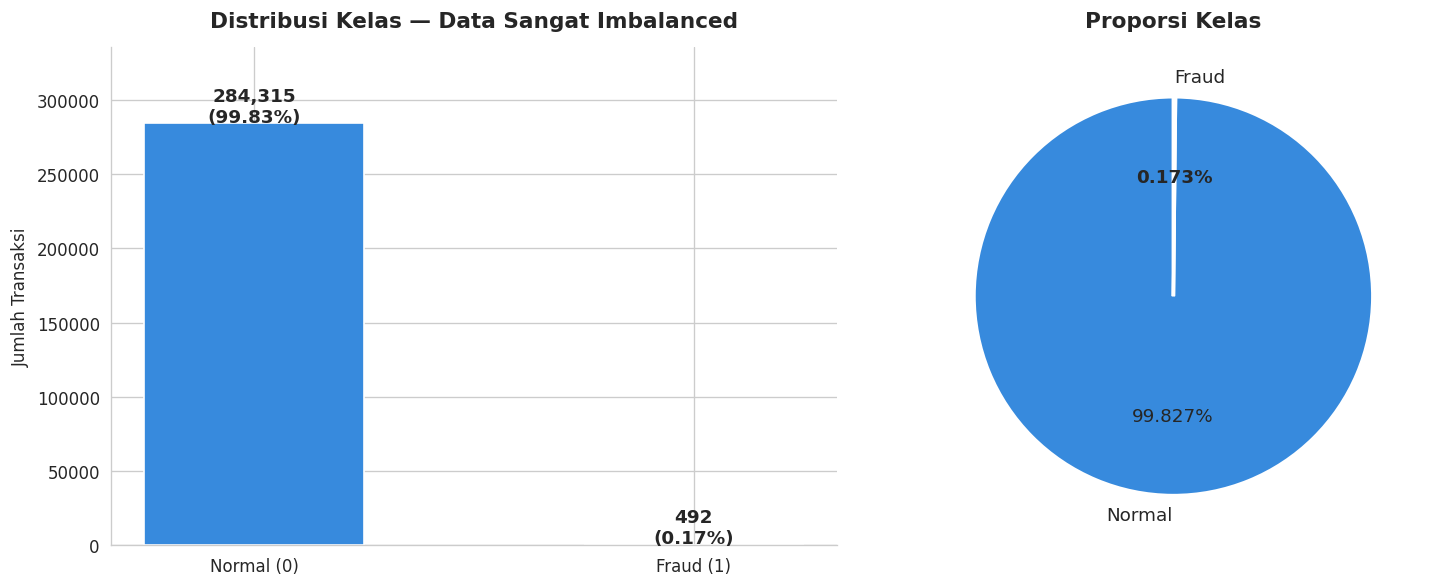

💾 Gambar disimpan: 01_distribusi_kelas.png


In [7]:
# ── Distribusi kelas (inti masalah imbalanced data) ──────
fraud_count   = df['Class'].value_counts()
fraud_pct     = df['Class'].value_counts(normalize=True) * 100

print("=" * 60)
print("DISTRIBUSI KELAS")
print("=" * 60)
print(f"Normal (0) : {fraud_count[0]:,} transaksi ({fraud_pct[0]:.2f}%)")
print(f"Fraud  (1) : {fraud_count[1]:,} transaksi ({fraud_pct[1]:.4f}%)")
print(f"Rasio      : 1 fraud per {int(fraud_count[0]/fraud_count[1]):,} transaksi normal")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart distribusi
colors = ['#378ADD', '#D85A30']
axes[0].bar(['Normal (0)', 'Fraud (1)'], fraud_count.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Distribusi Kelas — Data Sangat Imbalanced', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Jumlah Transaksi')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({fraud_pct.values[i]:.2f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(fraud_count.values) * 1.18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    fraud_count.values, labels=['Normal', 'Fraud'],
    autopct='%1.3f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
autotexts[1].set_fontweight('bold')
axes[1].set_title('Proporsi Kelas', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('01_distribusi_kelas.png', bbox_inches='tight')
plt.show()
print("💾 Gambar disimpan: 01_distribusi_kelas.png")


Statistik Amount — Transaksi Normal:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Statistik Amount — Transaksi Fraud:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


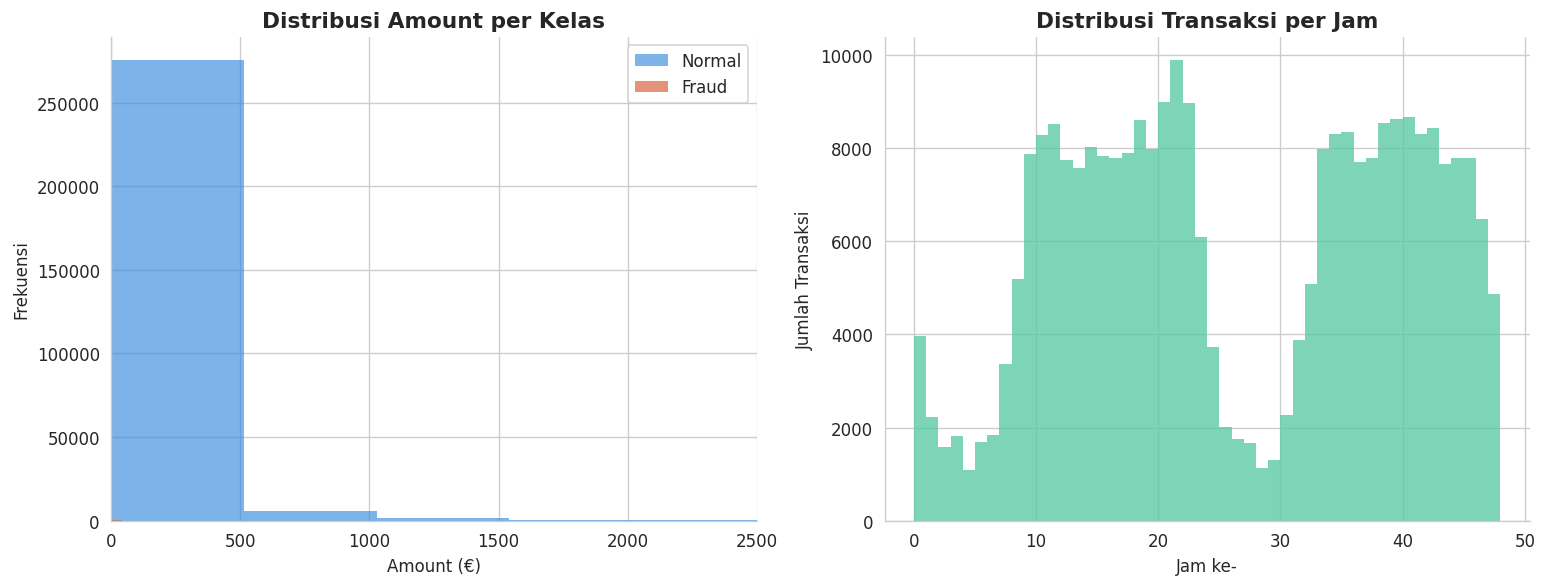

In [8]:
# ── Statistik Amount per kelas ───────────────────────────
print("Statistik Amount — Transaksi Normal:")
print(df[df['Class']==0]['Amount'].describe().round(2))
print()
print("Statistik Amount — Transaksi Fraud:")
print(df[df['Class']==1]['Amount'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribusi Amount
for cls, label, color in [(0, 'Normal', '#378ADD'), (1, 'Fraud', '#D85A30')]:
    subset = df[df['Class'] == cls]['Amount']
    axes[0].hist(subset, bins=50, alpha=0.65, label=label, color=color, edgecolor='none')
axes[0].set_title('Distribusi Amount per Kelas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].set_xlim(0, 2500)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Distribusi Time
axes[1].hist(df['Time'] / 3600, bins=48, color='#5DCAA5', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribusi Transaksi per Jam', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam ke-')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('02_amount_time.png', bbox_inches='tight')
plt.show()


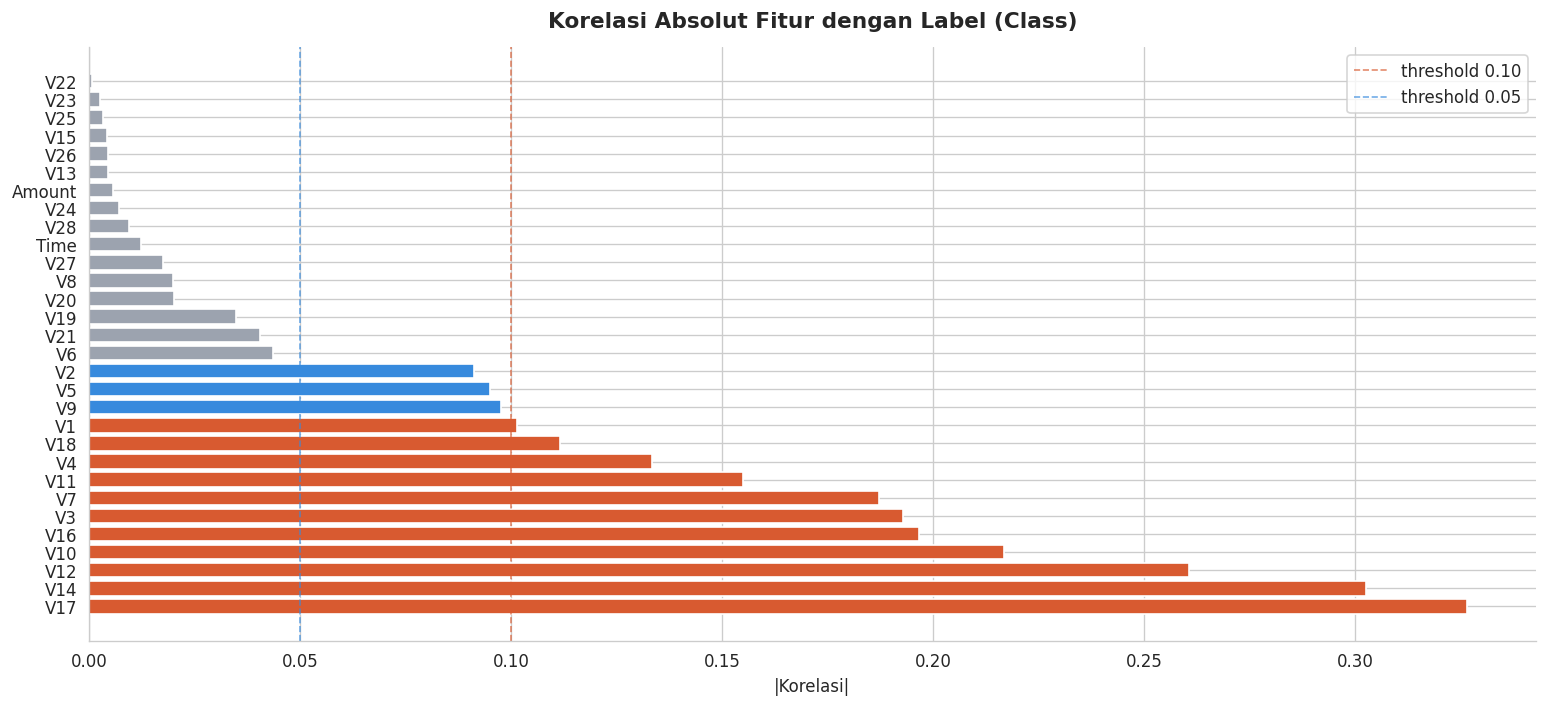

Top 10 fitur paling berkorelasi dengan fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [9]:
# ── Korelasi fitur dengan label Class ───────────────────
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(corr_with_class.index, corr_with_class.values,
               color=['#D85A30' if v > 0.1 else '#378ADD' if v > 0.05 else '#9ca3af'
                      for v in corr_with_class.values])
ax.set_title('Korelasi Absolut Fitur dengan Label (Class)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('|Korelasi|')
ax.axvline(0.1, color='#D85A30', linestyle='--', linewidth=1, alpha=0.7, label='threshold 0.10')
ax.axvline(0.05, color='#378ADD', linestyle='--', linewidth=1, alpha=0.7, label='threshold 0.05')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('03_korelasi_fitur.png', bbox_inches='tight')
plt.show()

print("Top 10 fitur paling berkorelasi dengan fraud:")
print(corr_with_class.head(10).to_string())


## 3. Preprocessing

**Langkah-langkah:**
1. Normalisasi fitur `Amount` dan `Time` (V1–V28 sudah di-scale via PCA)
2. Hapus duplikat
3. Train/Test split stratified (80/20)
4. SMOTE diterapkan **hanya** pada training set
5. Genetic Algorithm untuk seleksi fitur optimal


In [10]:
# ── Hapus duplikat ────────────────────────────────────────
n_before = len(df)
df = df.drop_duplicates()
print(f"Duplikat dihapus: {n_before - len(df)} baris")
print(f"Shape setelah  : {df.shape}")

# ── Normalisasi Amount & Time ─────────────────────────────
scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler_time.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

print("\n✅ Amount dan Time berhasil dinormalisasi (2 scaler terpisah)")
print(f"   Fitur tersedia: {df.shape[1] - 1} fitur + 1 label")

Duplikat dihapus: 1081 baris
Shape setelah  : (283726, 31)

✅ Amount dan Time berhasil dinormalisasi (2 scaler terpisah)
   Fitur tersedia: 30 fitur + 1 label


In [11]:
# ── Train / Validation / Test Split ────────────────────────────────────
RANDOM_STATE = 42

X = df.drop('Class', axis=1)
y = df['Class']

# 1. Split pertama: 80% Train, 20% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2. Split kedua: Temp dibagi 2 jadi 10% Validation, 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("=" * 50)
print("HASIL SPLIT DATA")
print("=" * 50)
print(f"Training set (80%)   : {X_train.shape[0]:,} sampel")
print(f"  - Normal   : {(y_train==0).sum():,}")
print(f"  - Fraud    : {(y_train==1).sum():,}")
print(f"Validation set (10%) : {X_val.shape[0]:,} sampel")
print(f"  - Normal   : {(y_val==0).sum():,}")
print(f"  - Fraud    : {(y_val==1).sum():,}")
print(f"Test set (10%)       : {X_test.shape[0]:,} sampel")
print(f"  - Normal   : {(y_test==0).sum():,}")
print(f"  - Fraud    : {(y_test==1).sum():,}")
print()
print("⚠️  Validation set digunakan untuk GA, Test set HANYA untuk evaluasi akhir")


HASIL SPLIT DATA
Training set (80%)   : 226,980 sampel
  - Normal   : 226,602
  - Fraud    : 378
Validation set (10%) : 28,373 sampel
  - Normal   : 28,325
  - Fraud    : 48
Test set (10%)       : 28,373 sampel
  - Normal   : 28,326
  - Fraud    : 47

⚠️  Validation set digunakan untuk GA, Test set HANYA untuk evaluasi akhir


HASIL SMOTE (hanya training set)
Sebelum SMOTE:
  Normal : 226,602
  Fraud  : 378

Setelah SMOTE (sampling_strategy=1.0):
  Normal : 226,602
  Fraud  : 45,320
  Rasio  : 1 Normal : 0 Fraud

✅ SMOTE selesai — distribusi kelas sekarang seimbang 1:1


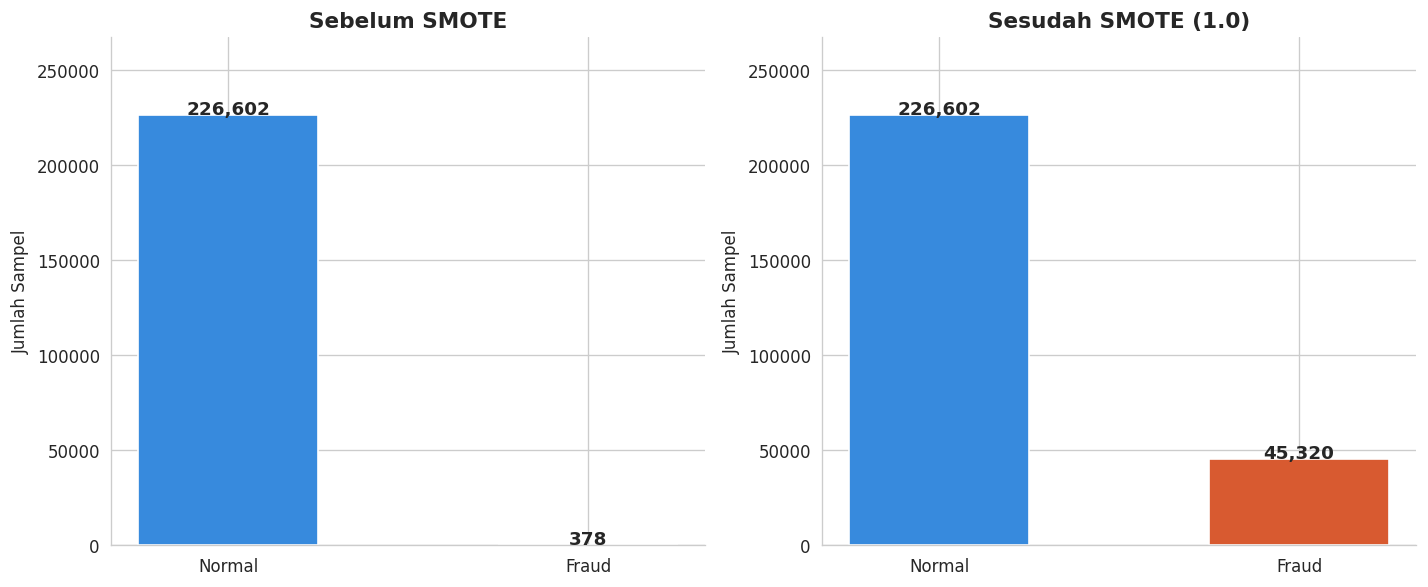

In [12]:
# ── SMOTE pada Training Set ───────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5, sampling_strategy=0.2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=" * 50)
print("HASIL SMOTE (hanya training set)")
print("=" * 50)
print(f"Sebelum SMOTE:")
print(f"  Normal : {(y_train==0).sum():,}")
print(f"  Fraud  : {(y_train==1).sum():,}")
print(f"\nSetelah SMOTE (sampling_strategy=1.0):")
print(f"  Normal : {(y_train_smote==0).sum():,}")
print(f"  Fraud  : {(y_train_smote==1).sum():,}")
ratio = (y_train_smote==1).sum() / (y_train_smote==0).sum()
print(f"  Rasio  : 1 Normal : {ratio:.0f} Fraud")
print(f"\n✅ SMOTE selesai — distribusi kelas sekarang seimbang 1:1")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#378ADD', '#D85A30']
for ax, counts, title in [
    (axes[0], Counter(y_train),       'Sebelum SMOTE'),
    (axes[1], Counter(y_train_smote), 'Sesudah SMOTE (1.0)')
]:
    vals = [counts[0], counts[1]]
    bars = ax.bar(['Normal', 'Fraud'], vals, color=colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('04_smote_comparison.png', bbox_inches='tight')
plt.show()

## 4. Genetic Algorithm — Seleksi Fitur

GA akan mencari subset fitur terbaik dari 30 fitur yang tersedia.
- **Kromosom**: string biner (1 = fitur dipilih, 0 = dibuang)
- **Fitness**: F1-score dari 3-fold cross-validation dengan Random Forest (cepat)
- **Operator**: seleksi turnamen, crossover satu titik, mutasi bit-flip


In [13]:
class GeneticAlgorithmFS:
    """Genetic Algorithm untuk seleksi fitur."""

    def __init__(self, n_features, pop_size=15, n_generations=20,
                 mutation_rate=0.05, crossover_rate=0.8, random_state=42):
        self.n_features     = n_features
        self.pop_size       = pop_size
        self.n_generations  = n_generations
        self.mutation_rate  = mutation_rate
        self.crossover_rate = crossover_rate
        self.random_state   = random_state
        self.best_fitness_history = []
        self.avg_fitness_history  = []
        self.best_chromosome_     = None
        self.best_features_       = None
        random.seed(random_state)
        np.random.seed(random_state)

    def _init_population(self):
        pop = []
        for _ in range(self.pop_size):
            chrom = np.random.randint(0, 2, self.n_features)
            if chrom.sum() < 3:
                idx = np.random.choice(self.n_features, 3, replace=False)
                chrom[idx] = 1
            pop.append(chrom)
        return pop

    def _fitness(self, chrom, X, y):
        selected = np.where(chrom == 1)[0]
        if len(selected) == 0:
            return 0.0
        X_sel = X[:, selected]
        # ✅ FIX 1: Decision Tree jauh lebih cepat dari Random Forest
        clf = DecisionTreeClassifier(max_depth=8, random_state=self.random_state)
        # ✅ FIX 2: 2-fold CV, bukan 3-fold
        cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=self.random_state)
        scores = cross_val_score(clf, X_sel, y, cv=cv, scoring='f1', n_jobs=-1)
        return scores.mean()

    def _tournament_select(self, pop, fitnesses, k=3):
        idx = random.sample(range(len(pop)), k)
        best = max(idx, key=lambda i: fitnesses[i])
        return pop[best].copy()

    def _crossover(self, p1, p2):
        if random.random() < self.crossover_rate:
            pt = random.randint(1, self.n_features - 1)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])
            return c1, c2
        return p1.copy(), p2.copy()

    def _mutate(self, chrom):
        for i in range(self.n_features):
            if random.random() < self.mutation_rate:
                chrom[i] = 1 - chrom[i]
        if chrom.sum() == 0:
            chrom[random.randint(0, self.n_features-1)] = 1
        return chrom

    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        # ✅ FIX 3: Subsample 5000 data untuk fitness evaluation
        # GA hanya butuh ranking RELATIF antar kromosom, bukan akurasi absolut
        max_samples = 5000
        if len(y) > max_samples:
            idx = np.random.choice(len(y), max_samples, replace=False)
            X_fit, y_fit = X[idx], y[idx]
            if len(np.unique(y_fit)) < 2:  # pastikan kedua kelas ada
                X_fit, y_fit = X, y
        else:
            X_fit, y_fit = X, y

        pop = self._init_population()
        best_fit   = -1
        best_chrom = None

        for gen in range(self.n_generations):
            fitnesses = [self._fitness(c, X_fit, y_fit) for c in pop]

            gen_best = max(fitnesses)
            gen_avg  = np.mean(fitnesses)
            self.best_fitness_history.append(gen_best)
            self.avg_fitness_history.append(gen_avg)

            if gen_best > best_fit:
                best_fit   = gen_best
                best_chrom = pop[np.argmax(fitnesses)].copy()

            elite_idx = np.argsort(fitnesses)[-2:]
            new_pop   = [pop[i].copy() for i in elite_idx]

            while len(new_pop) < self.pop_size:
                p1 = self._tournament_select(pop, fitnesses)
                p2 = self._tournament_select(pop, fitnesses)
                c1, c2 = self._crossover(p1, p2)
                new_pop.append(self._mutate(c1))
                if len(new_pop) < self.pop_size:
                    new_pop.append(self._mutate(c2))

            pop = new_pop
            print(f"  Generasi {gen+1:2d}/{self.n_generations} | "
                  f"Best F1: {gen_best:.4f} | Avg F1: {gen_avg:.4f} | "
                  f"Fitur: {best_chrom.sum()}")

        self.best_chromosome_ = best_chrom
        self.best_features_   = np.where(best_chrom == 1)[0]
        print(f"\n✅ GA selesai! Fitur terpilih: {len(self.best_features_)} dari {self.n_features}")
        print(f"   Best F1 (CV): {best_fit:.4f}")
        return self

print("✅ Kelas GeneticAlgorithmFS siap digunakan")

✅ Kelas GeneticAlgorithmFS siap digunakan


In [14]:
import time

# ── Jalankan GA ───────────────────────────────────────────
print("🧬 Menjalankan Genetic Algorithm...")
print("   (Proses ini membutuhkan beberapa menit)")
print("-" * 55)

t0 = time.time() # Initialize t0 here
ga = GeneticAlgorithmFS(
    n_features     = X_train.shape[1],
    pop_size       = 15,   # ← dari 20
    n_generations  = 20,   # ← dari 30
    mutation_rate  = 0.05,
    crossover_rate = 0.8,
    random_state   = RANDOM_STATE
)
ga.fit(X_train_smote, y_train_smote)
elapsed = time.time() - t0

print(f"\n⏱️  Waktu GA: {elapsed/60:.1f} menit")
print(f"\nFitur terpilih GA ({len(ga.best_features_)} fitur):")
selected_features = X_train.columns[ga.best_features_].tolist()
print(selected_features)

🧬 Menjalankan Genetic Algorithm...
   (Proses ini membutuhkan beberapa menit)
-------------------------------------------------------
  Generasi  1/20 | Best F1: 0.9156 | Avg F1: 0.9100 | Fitur: 17
  Generasi  2/20 | Best F1: 0.9185 | Avg F1: 0.9138 | Fitur: 16
  Generasi  3/20 | Best F1: 0.9203 | Avg F1: 0.9146 | Fitur: 14
  Generasi  4/20 | Best F1: 0.9203 | Avg F1: 0.9160 | Fitur: 14
  Generasi  5/20 | Best F1: 0.9224 | Avg F1: 0.9155 | Fitur: 14
  Generasi  6/20 | Best F1: 0.9239 | Avg F1: 0.9178 | Fitur: 13
  Generasi  7/20 | Best F1: 0.9239 | Avg F1: 0.9177 | Fitur: 13
  Generasi  8/20 | Best F1: 0.9239 | Avg F1: 0.9192 | Fitur: 13
  Generasi  9/20 | Best F1: 0.9251 | Avg F1: 0.9187 | Fitur: 15
  Generasi 10/20 | Best F1: 0.9251 | Avg F1: 0.9197 | Fitur: 15
  Generasi 11/20 | Best F1: 0.9251 | Avg F1: 0.9212 | Fitur: 15
  Generasi 12/20 | Best F1: 0.9258 | Avg F1: 0.9206 | Fitur: 13
  Generasi 13/20 | Best F1: 0.9258 | Avg F1: 0.9206 | Fitur: 13
  Generasi 14/20 | Best F1: 0.9277

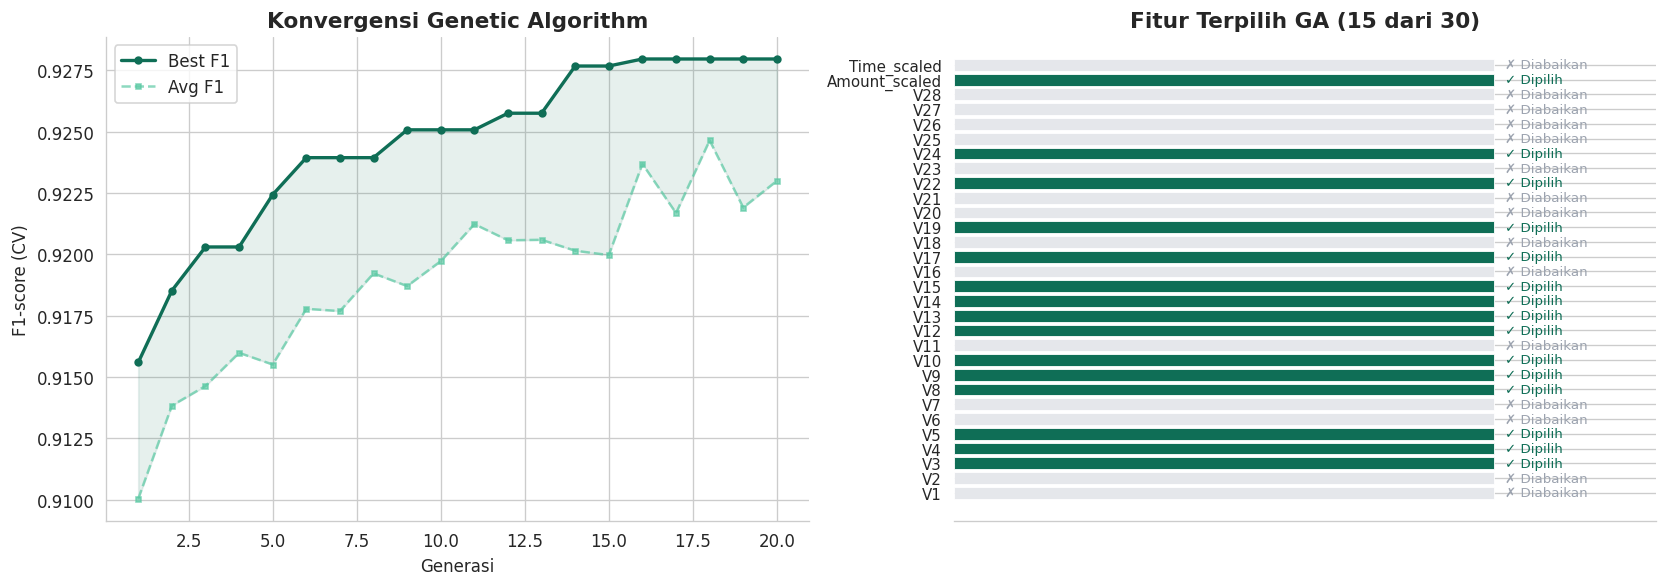

In [15]:
# ── Visualisasi Konvergensi GA ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gens = range(1, ga.n_generations + 1)
axes[0].plot(gens, ga.best_fitness_history, 'o-', color='#0F6E56',
             linewidth=2, markersize=4, label='Best F1')
axes[0].plot(gens, ga.avg_fitness_history, 's--', color='#5DCAA5',
             linewidth=1.5, markersize=3, alpha=0.7, label='Avg F1')
axes[0].fill_between(gens, ga.avg_fitness_history, ga.best_fitness_history,
                     alpha=0.1, color='#0F6E56')
axes[0].set_title('Konvergensi Genetic Algorithm', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Generasi')
axes[0].set_ylabel('F1-score (CV)')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Visualisasi kromosom terbaik
chrom = ga.best_chromosome_
feat_names = X_train.columns.tolist()
colors_chrom = ['#0F6E56' if c == 1 else '#e5e7eb' for c in chrom]
axes[1].barh(range(len(chrom)), [1]*len(chrom), color=colors_chrom,
             edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(chrom)))
axes[1].set_yticklabels(feat_names, fontsize=9)
axes[1].set_xlim(0, 1.3)
axes[1].set_title(f'Fitur Terpilih GA ({chrom.sum()} dari {len(chrom)})',
                  fontsize=13, fontweight='bold')
axes[1].set_xticks([])
for i, (c, name) in enumerate(zip(chrom, feat_names)):
    label = "✓ Dipilih" if c == 1 else "✗ Diabaikan"
    color = '#0F6E56' if c == 1 else '#9ca3af'
    axes[1].text(1.02, i, label, va='center', fontsize=8, color=color)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('05_ga_konvergensi.png', bbox_inches='tight')
plt.show()


In [16]:
# ── Siapkan 4 versi data untuk 12 eksperimen ─────────────
# Kondisi 1: Tanpa SMOTE, Tanpa GA (baseline)
X_tr_noSmote_noGA = X_train.values
y_tr_noSmote_noGA = y_train.values

# Kondisi 2: Dengan SMOTE, Tanpa GA
X_tr_smote_noGA   = X_train_smote.values
y_tr_smote_noGA   = y_train_smote.values

# Kondisi 3: Tanpa SMOTE, Dengan GA
X_tr_noSmote_GA   = X_train.values[:, ga.best_features_]
y_tr_noSmote_GA   = y_train.values

# Kondisi 4: Dengan SMOTE, Dengan GA (optimal)
X_tr_smote_GA     = X_train_smote.values[:, ga.best_features_]
y_tr_smote_GA     = y_train_smote.values

# Test set dalam dua versi (semua fitur vs fitur GA)
X_te_all  = X_test.values
X_te_GA   = X_test.values[:, ga.best_features_]
y_te      = y_test.values

print("✅ 4 versi data siap:")
print(f"  noSmote+noGA : {X_tr_noSmote_noGA.shape}")
print(f"  smote+noGA   : {X_tr_smote_noGA.shape}")
print(f"  noSmote+GA   : {X_tr_noSmote_GA.shape}")
print(f"  smote+GA     : {X_tr_smote_GA.shape}")


✅ 4 versi data siap:
  noSmote+noGA : (226980, 30)
  smote+noGA   : (271922, 30)
  noSmote+GA   : (226980, 15)
  smote+GA     : (271922, 15)


## 5. 12 Eksperimen

| # | Model | SMOTE | GA | Keterangan |
|---|-------|-------|----|------------|
| 1 | Decision Tree | ✗ | ✗ | Baseline |
| 2 | Decision Tree | ✓ | ✗ | +SMOTE |
| 3 | Decision Tree | ✗ | ✓ | +GA |
| 4 | Decision Tree | ✓ | ✓ | Optimal |
| 5 | Random Forest | ✗ | ✗ | Baseline |
| 6 | Random Forest | ✓ | ✗ | +SMOTE |
| 7 | Random Forest | ✗ | ✓ | +GA |
| 8 | Random Forest | ✓ | ✓ | Optimal |
| 9 | SVM | ✗ | ✗ | Baseline |
| 10 | SVM | ✓ | ✗ | +SMOTE |
| 11 | SVM | ✗ | ✓ | +GA |
| 12 | SVM | ✓ | ✓ | Optimal |


In [17]:
# ── Fungsi Evaluasi & Persiapan ───────────────────────────
import gc

def evaluate_model(model, X_train, y_train, X_test, y_test, name=""):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'name'      : name,
        'accuracy'  : round((tp+tn)/(tp+tn+fp+fn)*100, 2),
        'precision' : round(precision_score(y_test, y_pred, zero_division=0)*100, 2),
        'recall'    : round(recall_score(y_test, y_pred, zero_division=0)*100, 2),
        'f1'        : round(f1_score(y_test, y_pred, zero_division=0)*100, 2),
        'auc_roc'   : round(roc_auc_score(y_test, y_prob)*100, 2) if y_prob is not None else None,
        'tp':tp, 'fp':fp, 'tn':tn, 'fn':fn,
        'train_time': round(train_time, 2),
        'model'     : model,
        'y_prob'    : y_prob,
        'y_pred'    : y_pred
    }

# Inisialisasi list results (jangan dihapus antar batch!)
if 'results' not in dir():
    results = []
    print("✅ List results dibuat baru")
else:
    print(f"✅ List results sudah ada ({len(results)} eksperimen tersimpan)")

print("✅ Fungsi evaluate_model siap")

✅ List results dibuat baru
✅ Fungsi evaluate_model siap


In [18]:
# ═══════════════════════════════════════════════════════════
# BATCH 1 — DECISION TREE (4 eksperimen)
# Jalankan sel ini, tunggu selesai, baru jalankan Batch 2
# ═══════════════════════════════════════════════════════════

batch1 = [
    ("DT | noSMOTE | noGA",
     DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=RANDOM_STATE),
     X_tr_noSmote_noGA, y_tr_noSmote_noGA, X_te_all),

    ("DT | SMOTE | noGA",
     DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=RANDOM_STATE),
     X_tr_smote_noGA, y_tr_smote_noGA, X_te_all),

    ("DT | noSMOTE | GA",
     DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=RANDOM_STATE),
     X_tr_noSmote_GA, y_tr_noSmote_GA, X_te_GA),

    ("DT | SMOTE | GA",
     DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=RANDOM_STATE),
     X_tr_smote_GA, y_tr_smote_GA, X_te_GA),
]

print("🌳 BATCH 1 — Decision Tree")
print("=" * 60)
for i, (name, model, X_tr, y_tr, X_te) in enumerate(batch1, 1):
    print(f"  [{i}/4] {name} ...", end=' ', flush=True)
    res = evaluate_model(model, X_tr, y_tr, X_te, y_te, name=name)
    results.append(res)
    print(f"F1={res['f1']:.1f}% | Recall={res['recall']:.1f}% | "
          f"AUC={res['auc_roc']:.1f}% | ⏱{res['train_time']}s")

gc.collect()
print(f"\n✅ Batch 1 selesai! Total tersimpan: {len(results)}/12 eksperimen")
print("▶ Sekarang jalankan sel Batch 2")

🌳 BATCH 1 — Decision Tree
  [1/4] DT | noSMOTE | noGA ... F1=82.8% | Recall=76.6% | AUC=93.0% | ⏱15.12s
  [2/4] DT | SMOTE | noGA ... F1=38.0% | Recall=83.0% | AUC=88.3% | ⏱19.39s
  [3/4] DT | noSMOTE | GA ... F1=80.5% | Recall=74.5% | AUC=93.0% | ⏱7.27s
  [4/4] DT | SMOTE | GA ... F1=33.0% | Recall=78.7% | AUC=81.3% | ⏱8.97s

✅ Batch 1 selesai! Total tersimpan: 4/12 eksperimen
▶ Sekarang jalankan sel Batch 2


In [19]:
# ═══════════════════════════════════════════════════════════
# BATCH 2 — RANDOM FOREST (4 eksperimen)
# Jalankan SETELAH Batch 1 selesai
# ═══════════════════════════════════════════════════════════

batch2 = [
    ("RF | noSMOTE | noGA",
     RandomForestClassifier(n_estimators=100, max_depth=12,
                            random_state=RANDOM_STATE, n_jobs=-1),
     X_tr_noSmote_noGA, y_tr_noSmote_noGA, X_te_all),

    ("RF | SMOTE | noGA",
     RandomForestClassifier(n_estimators=100, max_depth=12,
                            random_state=RANDOM_STATE, n_jobs=-1),
     X_tr_smote_noGA, y_tr_smote_noGA, X_te_all),

    ("RF | noSMOTE | GA",
     RandomForestClassifier(n_estimators=100, max_depth=12,
                            random_state=RANDOM_STATE, n_jobs=-1),
     X_tr_noSmote_GA, y_tr_noSmote_GA, X_te_GA),

    ("RF | SMOTE | GA",
     RandomForestClassifier(n_estimators=100, max_depth=12,
                            random_state=RANDOM_STATE, n_jobs=-1),
     X_tr_smote_GA, y_tr_smote_GA, X_te_GA),
]

print("🌲 BATCH 2 — Random Forest")
print("=" * 60)
for i, (name, model, X_tr, y_tr, X_te) in enumerate(batch2, 1):
    print(f"  [{i}/4] {name} ...", end=' ', flush=True)
    res = evaluate_model(model, X_tr, y_tr, X_te, y_te, name=name)
    results.append(res)
    print(f"F1={res['f1']:.1f}% | Recall={res['recall']:.1f}% | "
          f"AUC={res['auc_roc']:.1f}% | ⏱{res['train_time']}s")

gc.collect()
print(f"\n✅ Batch 2 selesai! Total tersimpan: {len(results)}/12 eksperimen")
print("▶ Sekarang jalankan sel Batch 3")

🌲 BATCH 2 — Random Forest
  [1/4] RF | noSMOTE | noGA ... F1=87.1% | Recall=78.7% | AUC=98.8% | ⏱149.8s
  [2/4] RF | SMOTE | noGA ... F1=78.7% | Recall=78.7% | AUC=98.6% | ⏱164.39s
  [3/4] RF | noSMOTE | GA ... F1=84.7% | Recall=76.6% | AUC=98.7% | ⏱103.28s
  [4/4] RF | SMOTE | GA ... F1=78.7% | Recall=78.7% | AUC=98.0% | ⏱104.48s

✅ Batch 2 selesai! Total tersimpan: 8/12 eksperimen
▶ Sekarang jalankan sel Batch 3


In [20]:
# ═══════════════════════════════════════════════════════════
# BATCH 3 — SVM (4 eksperimen)
# SVM SANGAT LAMBAT dengan data besar → pakai subsample 10k
# untuk training, evaluasi tetap di test set penuh
# Jalankan SETELAH Batch 2 selesai
# ═══════════════════════════════════════════════════════════

def subsample_train(X_tr, y_tr, max_n=10000, random_state=42):
    """Subsample training data untuk SVM. Evaluasi tetap di test set penuh."""
    if len(y_tr) <= max_n:
        return X_tr, y_tr
    np.random.seed(random_state)
    # Stratified subsample: ambil proporsional dari tiap kelas
    classes, counts = np.unique(y_tr, return_counts=True)
    idx_selected = []
    for cls, cnt in zip(classes, counts):
        cls_idx = np.where(y_tr == cls)[0]
        n_take  = min(cnt, int(max_n * cnt / len(y_tr)))
        n_take  = max(n_take, 50)  # minimal 50 per kelas
        chosen  = np.random.choice(cls_idx, n_take, replace=False)
        idx_selected.extend(chosen)
    np.random.shuffle(idx_selected)
    print(f"    Subsample: {len(y_tr):,} → {len(idx_selected):,} sampel "
          f"({Counter(y_tr[idx_selected])})")
    return X_tr[idx_selected], y_tr[idx_selected]

# Data SVM: subsample semua training set (terutama yg sudah di-SMOTE)
print("📊 Menyiapkan subsample untuk SVM...")
X_svm_noSmote_noGA, y_svm_noSmote_noGA = subsample_train(
    X_tr_noSmote_noGA, y_tr_noSmote_noGA)
X_svm_smote_noGA, y_svm_smote_noGA     = subsample_train(
    X_tr_smote_noGA,   y_tr_smote_noGA)
X_svm_noSmote_GA, y_svm_noSmote_GA     = subsample_train(
    X_tr_noSmote_GA,   y_tr_noSmote_GA)
X_svm_smote_GA, y_svm_smote_GA         = subsample_train(
    X_tr_smote_GA,     y_tr_smote_GA)

batch3 = [
    ("SVM | noSMOTE | noGA",
     SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
     X_svm_noSmote_noGA, y_svm_noSmote_noGA, X_te_all),

    ("SVM | SMOTE | noGA",
     SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
     X_svm_smote_noGA, y_svm_smote_noGA, X_te_all),

    ("SVM | noSMOTE | GA",
     SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
     X_svm_noSmote_GA, y_svm_noSmote_GA, X_te_GA),

    ("SVM | SMOTE | GA",
     SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
     X_svm_smote_GA, y_svm_smote_GA, X_te_GA),
]

print("\n⚡ BATCH 3 — SVM (dengan subsample training 10k)")
print("=" * 60)
for i, (name, model, X_tr, y_tr, X_te) in enumerate(batch3, 1):
    print(f"  [{i}/4] {name} ...", end=' ', flush=True)
    res = evaluate_model(model, X_tr, y_tr, X_te, y_te, name=name)
    results.append(res)
    print(f"F1={res['f1']:.1f}% | Recall={res['recall']:.1f}% | "
          f"AUC={res['auc_roc']:.1f}% | ⏱{res['train_time']}s")

gc.collect()
print(f"\n✅ Batch 3 selesai! Total tersimpan: {len(results)}/12 eksperimen")

# Verifikasi semua 12 eksperimen ada
expected = [
    'DT | noSMOTE | noGA', 'DT | SMOTE | noGA',
    'DT | noSMOTE | GA',   'DT | SMOTE | GA',
    'RF | noSMOTE | noGA', 'RF | SMOTE | noGA',
    'RF | noSMOTE | GA',   'RF | SMOTE | GA',
    'SVM | noSMOTE | noGA','SVM | SMOTE | noGA',
    'SVM | noSMOTE | GA',  'SVM | SMOTE | GA',
]
names_done = [r['name'] for r in results]
missing = [e for e in expected if e not in names_done]
if missing:
    print(f"\n⚠️  Eksperimen belum selesai: {missing}")
else:
    print("\n🎉 Semua 12 eksperimen selesai! Lanjutkan ke sel Visualisasi.")

📊 Menyiapkan subsample untuk SVM...
    Subsample: 226,980 → 10,033 sampel (Counter({np.int64(0): 9983, np.int64(1): 50}))
    Subsample: 271,922 → 9,999 sampel (Counter({np.int64(0): 8333, np.int64(1): 1666}))
    Subsample: 226,980 → 10,033 sampel (Counter({np.int64(0): 9983, np.int64(1): 50}))
    Subsample: 271,922 → 9,999 sampel (Counter({np.int64(0): 8333, np.int64(1): 1666}))

⚡ BATCH 3 — SVM (dengan subsample training 10k)
  [1/4] SVM | noSMOTE | noGA ... F1=59.1% | Recall=44.7% | AUC=93.0% | ⏱1.41s
  [2/4] SVM | SMOTE | noGA ... F1=57.3% | Recall=87.2% | AUC=99.0% | ⏱2.73s
  [3/4] SVM | noSMOTE | GA ... F1=53.5% | Recall=40.4% | AUC=93.7% | ⏱1.09s
  [4/4] SVM | SMOTE | GA ... F1=57.8% | Recall=87.2% | AUC=98.9% | ⏱2.9s

✅ Batch 3 selesai! Total tersimpan: 12/12 eksperimen

🎉 Semua 12 eksperimen selesai! Lanjutkan ke sel Visualisasi.


## 6. Hasil, Visualisasi & Perbandingan

In [21]:
# ── Tabel ringkasan semua eksperimen ─────────────────────
df_results = pd.DataFrame([{
    'Eksperimen' : r['name'],
    'Accuracy (%)': r['accuracy'],
    'Precision (%)': r['precision'],
    'Recall (%)' : r['recall'],
    'F1-score (%)': r['f1'],
    'AUC-ROC (%)': r['auc_roc'],
    'TP': r['tp'], 'FP': r['fp'],
    'TN': r['tn'], 'FN': r['fn'],
    'Waktu (s)'  : r['train_time']
} for r in results])

# Tambahkan kolom model & kondisi
df_results['Model'] = df_results['Eksperimen'].apply(
    lambda x: 'Decision Tree' if x.startswith('DT') else
              'Random Forest' if x.startswith('RF') else 'SVM')
df_results['SMOTE'] = df_results['Eksperimen'].apply(
    lambda x: '✓' if 'SMOTE |' in x else '✗')
df_results['GA'] = df_results['Eksperimen'].apply(
    lambda x: '✓' if x.endswith('GA') and 'noGA' not in x else '✗')

print("=" * 90)
print("TABEL LENGKAP 12 EKSPERIMEN")
print("=" * 90)
display_cols = ['Eksperimen', 'Precision (%)', 'Recall (%)', 'F1-score (%)', 'AUC-ROC (%)', 'FN']
print(df_results[display_cols].to_string(index=False))
print()
print("⭐ Model terbaik (F1-score tertinggi):")
best_row = df_results.loc[df_results['F1-score (%)'].idxmax()]
print(f"   {best_row['Eksperimen']} — F1: {best_row['F1-score (%)']:.2f}%")


TABEL LENGKAP 12 EKSPERIMEN
          Eksperimen  Precision (%)  Recall (%)  F1-score (%)  AUC-ROC (%)  FN
 DT | noSMOTE | noGA          90.00       76.60         82.76        93.01  11
   DT | SMOTE | noGA          24.68       82.98         38.05        88.26   8
   DT | noSMOTE | GA          87.50       74.47         80.46        92.99  12
     DT | SMOTE | GA          20.90       78.72         33.04        81.35  10
 RF | noSMOTE | noGA          97.37       78.72         87.06        98.83  10
   RF | SMOTE | noGA          78.72       78.72         78.72        98.59  10
   RF | noSMOTE | GA          94.74       76.60         84.71        98.69  11
     RF | SMOTE | GA          78.72       78.72         78.72        98.02  10
SVM | noSMOTE | noGA          87.50       44.68         59.15        92.95  26
  SVM | SMOTE | noGA          42.71       87.23         57.34        98.95   6
  SVM | noSMOTE | GA          79.17       40.43         53.52        93.72  28
    SVM | SMOTE | GA    

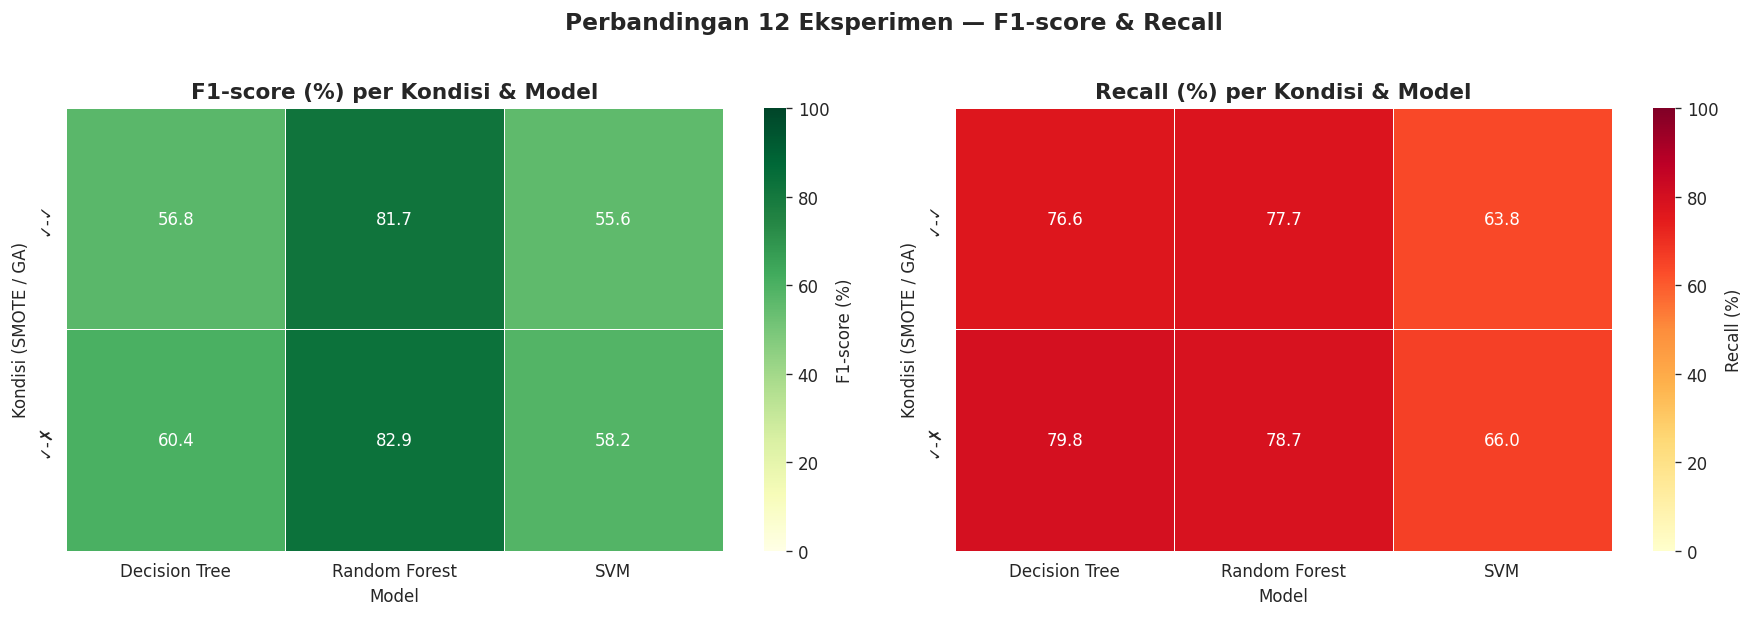

In [22]:
# ── Heatmap perbandingan F1-score ─────────────────────────
pivot_f1 = df_results.pivot_table(
    values='F1-score (%)',
    index=['SMOTE', 'GA'],
    columns='Model'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap F1
sns.heatmap(pivot_f1, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, ax=axes[0], vmin=0, vmax=100,
            cbar_kws={'label': 'F1-score (%)'})
axes[0].set_title('F1-score (%) per Kondisi & Model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Kondisi (SMOTE / GA)')

# Heatmap Recall (lebih penting untuk fraud detection)
pivot_rc = df_results.pivot_table(
    values='Recall (%)', index=['SMOTE', 'GA'], columns='Model')
sns.heatmap(pivot_rc, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=100,
            cbar_kws={'label': 'Recall (%)'})
axes[1].set_title('Recall (%) per Kondisi & Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Kondisi (SMOTE / GA)')

plt.suptitle('Perbandingan 12 Eksperimen — F1-score & Recall', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_heatmap_eksperimen.png', bbox_inches='tight')
plt.show()


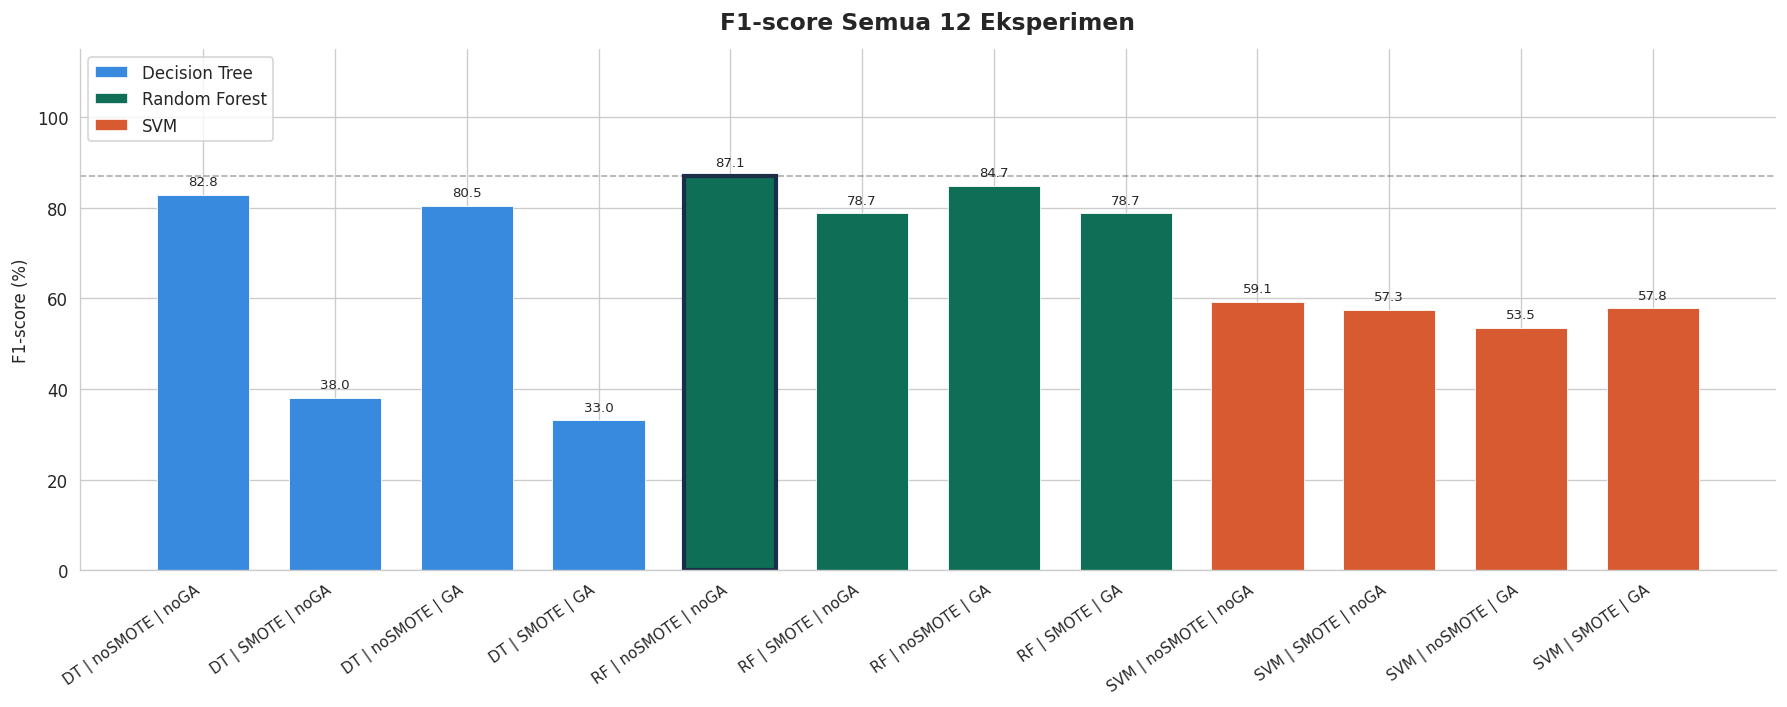

In [23]:
# ── Grouped bar chart — F1-score semua eksperimen ────────
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(df_results))
bars = ax.bar(x, df_results['F1-score (%)'],
              color=[PALETTE.get(m, '#888') for m in df_results['Model']],
              edgecolor='white', linewidth=0.5, width=0.7)

# Sorot model terbaik
best_idx = df_results['F1-score (%)'].idxmax()
bars[best_idx].set_edgecolor('#1a2e4a')
bars[best_idx].set_linewidth(2.5)

ax.set_xticks(x)
ax.set_xticklabels(df_results['Eksperimen'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1-score (%)')
ax.set_title('F1-score Semua 12 Eksperimen', fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, 115)
ax.axhline(df_results['F1-score (%)'].max(), color='#333', linestyle='--',
           linewidth=1, alpha=0.4)

for bar, val in zip(bars, df_results['F1-score (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m, c in PALETTE.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('07_grouped_bar_f1.png', bbox_inches='tight')
plt.show()


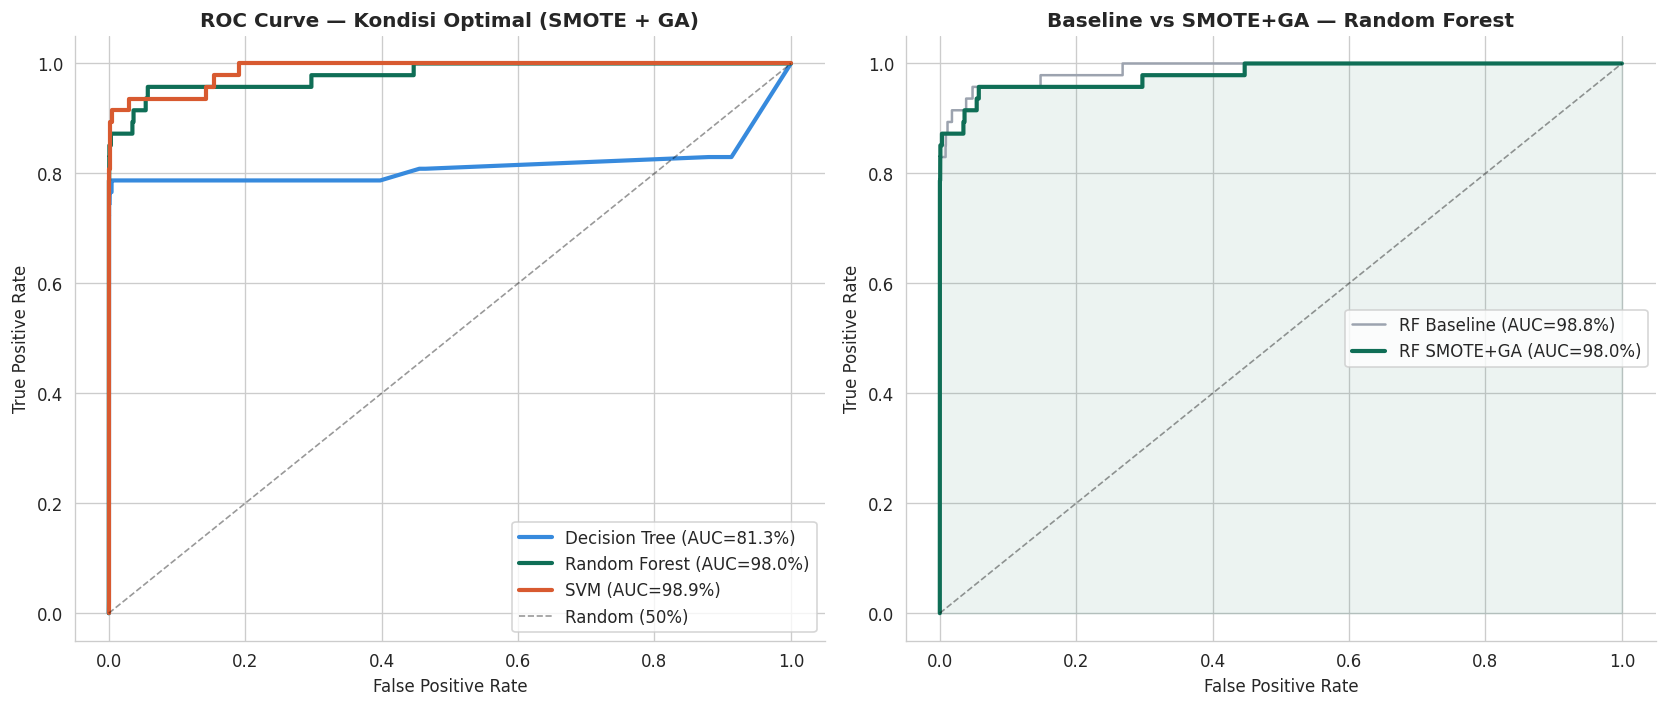

In [24]:
# ── ROC Curve — 4 kondisi optimal (SMOTE+GA) ─────────────
optimal_results = [r for r in results if 'SMOTE | GA' in r['name'] and 'noSMOTE' not in r['name'] and 'noGA' not in r['name']]

# Tambahkan baseline untuk perbandingan
baseline_results = [r for r in results if 'noSMOTE | noGA' in r['name']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC — kondisi optimal
for r in optimal_results:
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_te, r['y_prob'])
        model_name = r['name'].split(' | ')[0]
        model_full = {'DT': 'Decision Tree', 'RF': 'Random Forest', 'SVM': 'SVM'}[model_name]
        axes[0].plot(fpr, tpr, linewidth=2.5, label=f"{model_full} (AUC={r['auc_roc']:.1f}%)",
                     color=PALETTE[model_full])

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random (50%)')
axes[0].set_title('ROC Curve — Kondisi Optimal (SMOTE + GA)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ROC — baseline vs optimal (Random Forest sebagai contoh)
rf_base = next(r for r in results if r['name'] == 'RF | noSMOTE | noGA')
rf_opt  = next(r for r in results if r['name'] == 'RF | SMOTE | GA')

for r, label, color, lw in [
    (rf_base, f"RF Baseline (AUC={rf_base['auc_roc']:.1f}%)", '#9ca3af', 1.5),
    (rf_opt,  f"RF SMOTE+GA (AUC={rf_opt['auc_roc']:.1f}%)",  '#0F6E56', 2.5)
]:
    fpr, tpr, _ = roc_curve(y_te, r['y_prob'])
    axes[1].plot(fpr, tpr, linewidth=lw, label=label, color=color)

axes[1].fill_between(*roc_curve(y_te, rf_opt['y_prob'])[:2],
                     alpha=0.08, color='#0F6E56')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4)
axes[1].set_title('Baseline vs SMOTE+GA — Random Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('08_roc_curves.png', bbox_inches='tight')
plt.show()


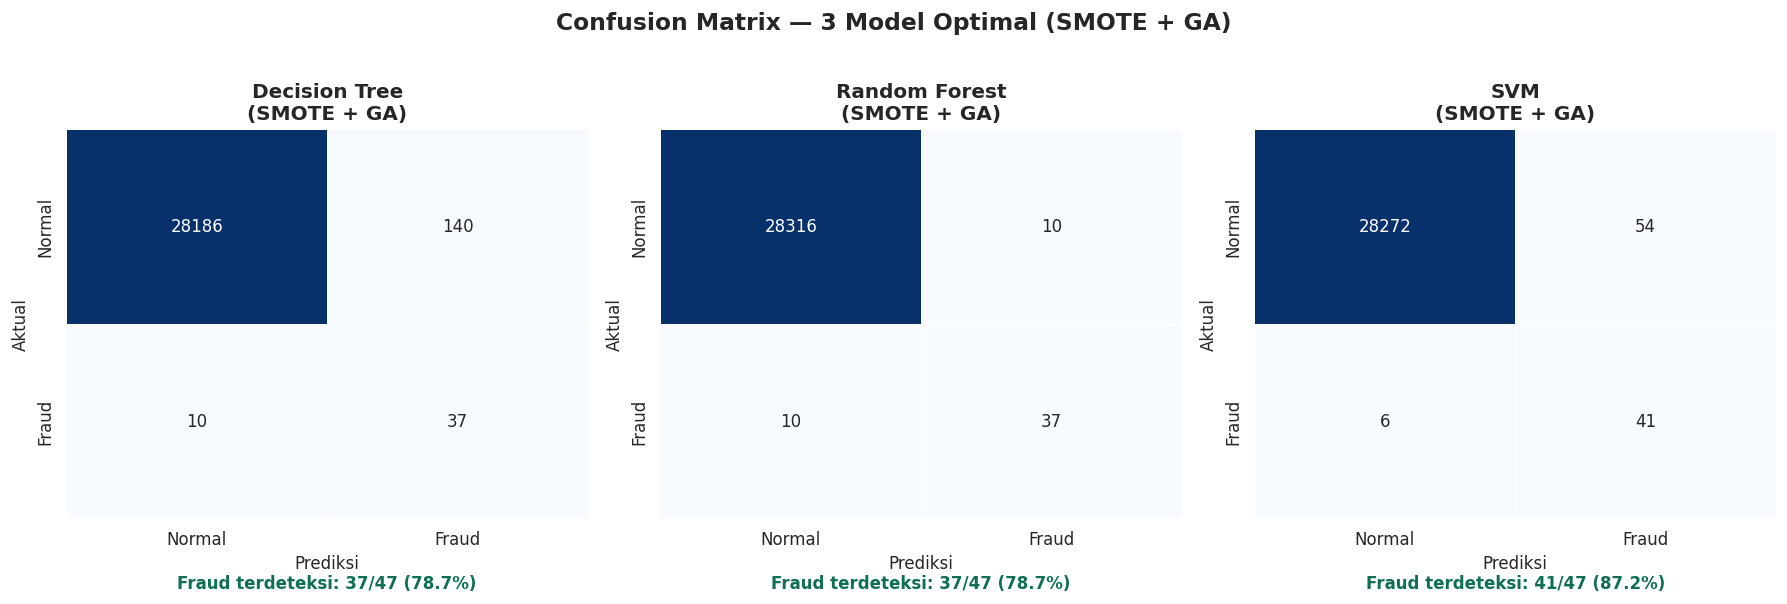

In [25]:
# ── Confusion Matrix — 3 model optimal ───────────────────
opt_names = ['DT | SMOTE | GA', 'RF | SMOTE | GA', 'SVM | SMOTE | GA']
opt_results_list = [r for r in results if r['name'] in opt_names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, r in zip(axes, opt_results_list):
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    model_name = r['name'].split(' | ')[0]
    model_full = {'DT': 'Decision Tree', 'RF': 'Random Forest', 'SVM': 'SVM'}[model_name]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                cbar=False, linewidths=0.5)
    ax.set_title(f'{model_full}\n(SMOTE + GA)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

    total_fraud = r['tp'] + r['fn']
    detected    = r['tp']
    missed      = r['fn']
    ax.text(0.5, -0.18,
            f"Fraud terdeteksi: {detected}/{total_fraud} ({detected/total_fraud*100:.1f}%)",
            transform=ax.transAxes, ha='center', fontsize=10,
            color='#0F6E56', fontweight='bold')

plt.suptitle('Confusion Matrix — 3 Model Optimal (SMOTE + GA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('09_confusion_matrix.png', bbox_inches='tight')
plt.show()


### Confusion Matrix untuk Semua 12 Eksperimen

Untuk melihat bagaimana setiap model bekerja di bawah kondisi yang berbeda (dengan/tanpa SMOTE, dengan/tanpa GA), kita akan memvisualisasikan confusion matrix untuk semua 12 eksperimen.

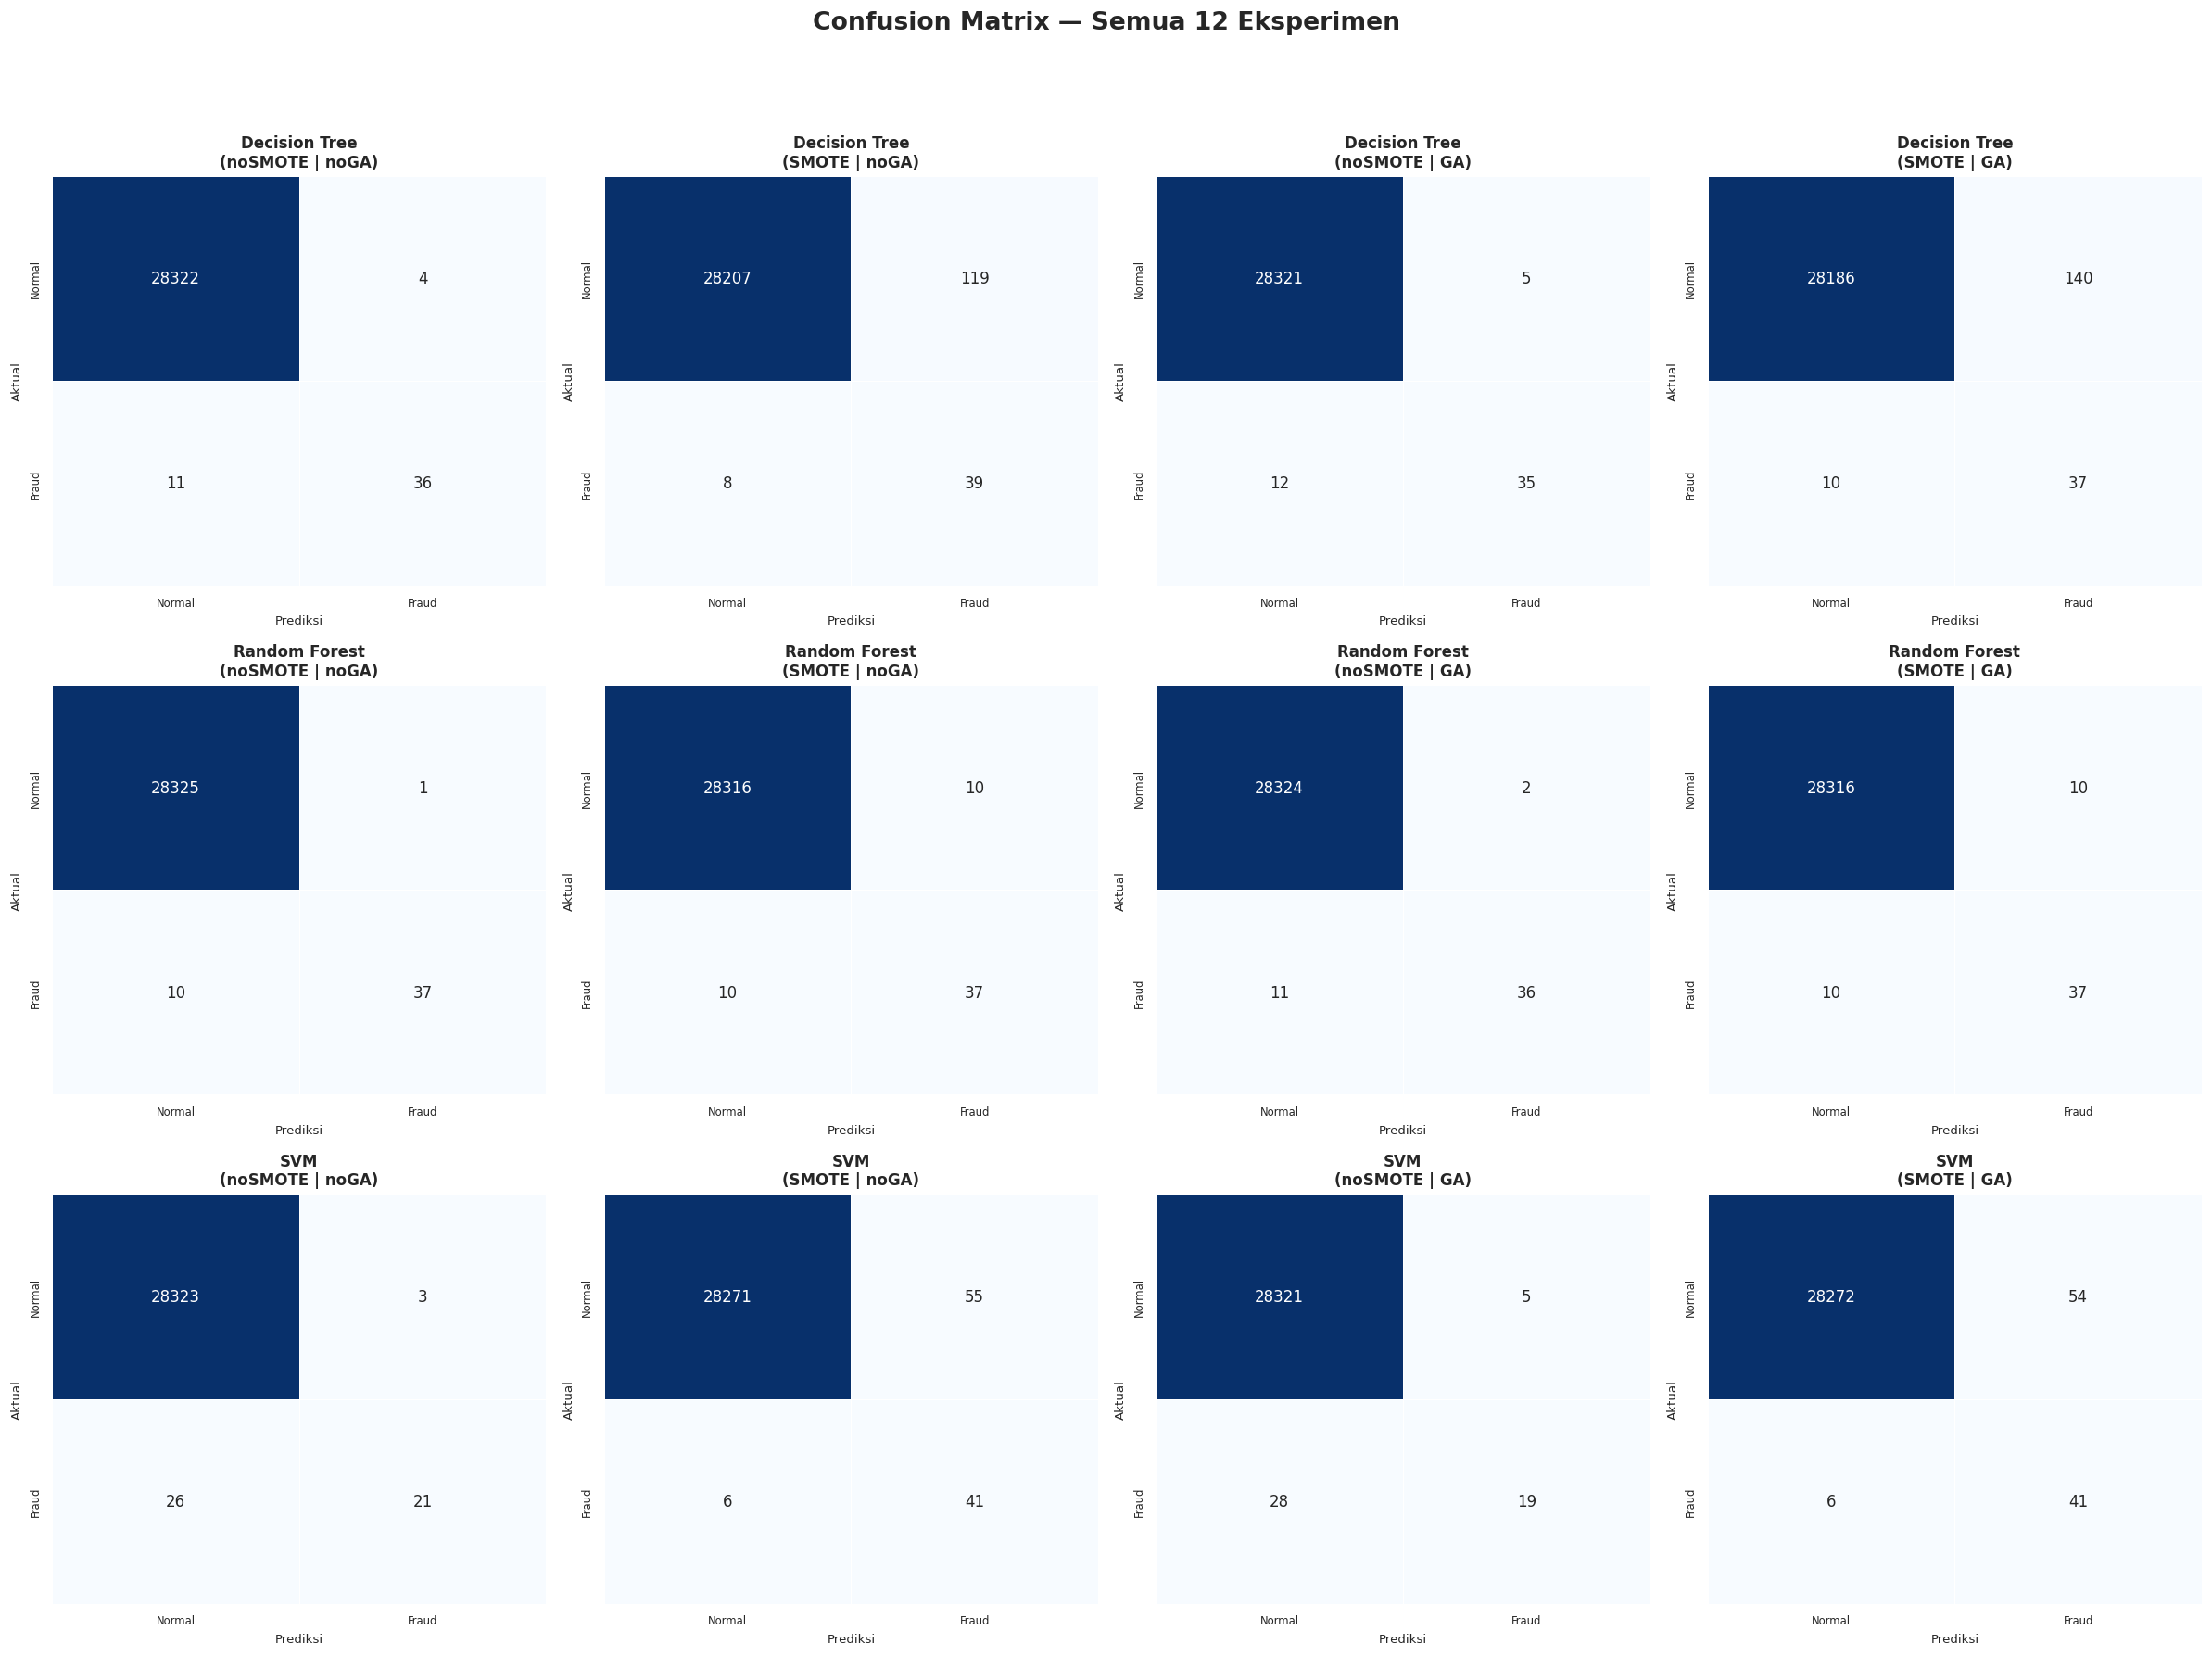

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, r in enumerate(results):
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    model_name_short = r['name'].split(' | ')[0]
    model_full = {'DT': 'Decision Tree', 'RF': 'Random Forest', 'SVM': 'SVM'}[model_name_short]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                cbar=False, linewidths=0.5)
    axes[i].set_title(f'{model_full}\n({r['name'].split(' | ')[1]} | {r['name'].split(' | ')[2]})',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Prediksi', fontsize=8)
    axes[i].set_ylabel('Aktual', fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)

plt.suptitle('Confusion Matrix — Semua 12 Eksperimen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.savefig('14_all_confusion_matrices.png', bbox_inches='tight')
plt.show()

### Ringkasan Komponen Confusion Matrix

Berikut adalah tabel ringkasan yang menampilkan True Positives (TP), False Positives (FP), True Negatives (TN), dan False Negatives (FN) untuk setiap eksperimen.

In [27]:
df_cm_summary = pd.DataFrame([
    {
        'Eksperimen' : r['name'],
        'True Positives (TP)': r['tp'],
        'False Positives (FP)': r['fp'],
        'True Negatives (TN)': r['tn'],
        'False Negatives (FN)': r['fn']
    } for r in results
])

print("=" * 70)
print("RINGKASAN KOMPONEN CONFUSION MATRIX UNTUK 12 EKSPERIMEN")
print("=" * 70)
display(df_cm_summary)


RINGKASAN KOMPONEN CONFUSION MATRIX UNTUK 12 EKSPERIMEN


,Eksperimen,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN)
0,DT | noSMOTE | noGA,36,4,28322,11
1,DT | SMOTE | noGA,39,119,28207,8
2,DT | noSMOTE | GA,35,5,28321,12
3,DT | SMOTE | GA,37,140,28186,10
4,RF | noSMOTE | noGA,37,1,28325,10
5,RF | SMOTE | noGA,37,10,28316,10
6,RF | noSMOTE | GA,36,2,28324,11
7,RF | SMOTE | GA,37,10,28316,10
8,SVM | noSMOTE | noGA,21,3,28323,26
9,SVM | SMOTE | noGA,41,55,28271,6


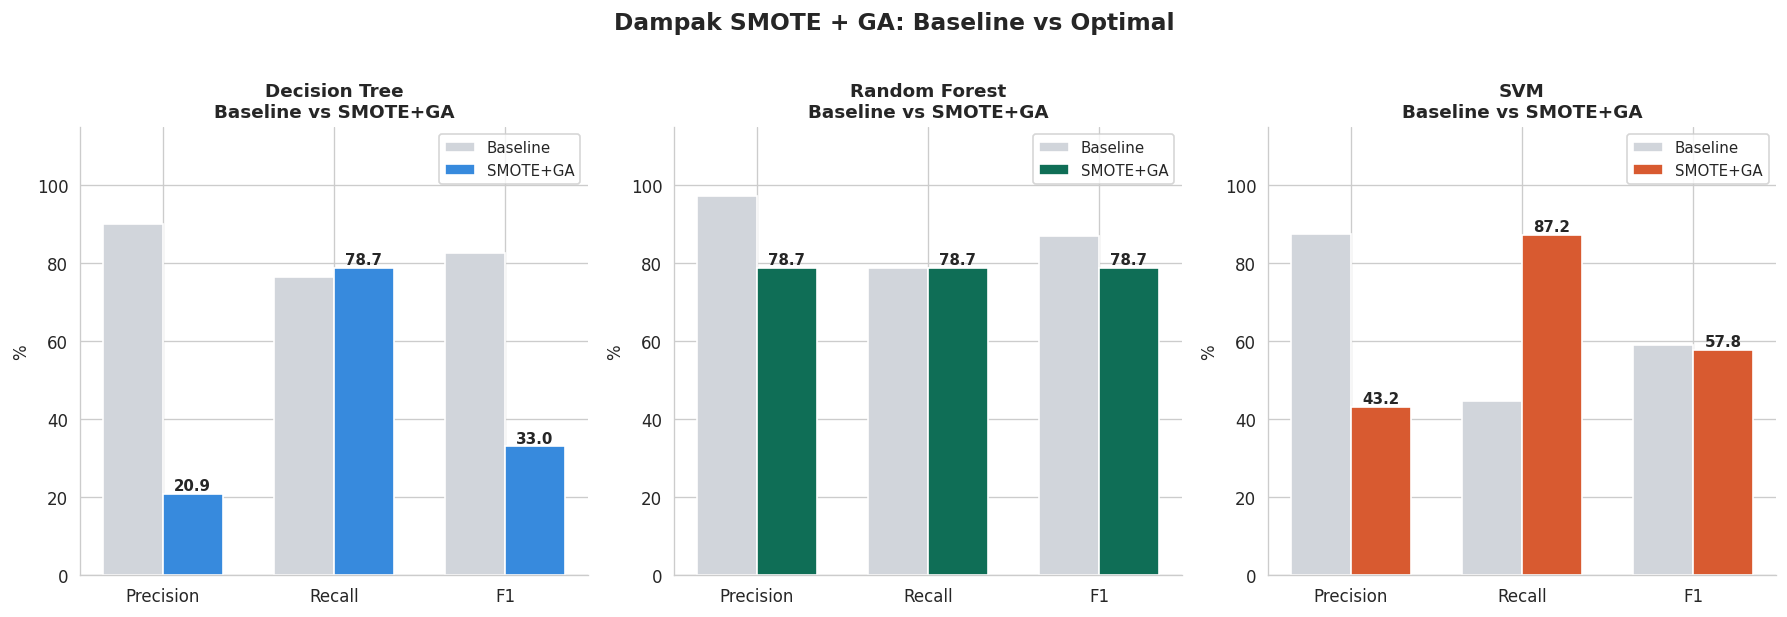

In [28]:
# ── Dampak SMOTE: sebelum vs sesudah (per model) ─────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_short = ['DT', 'RF', 'SVM']
models_full  = ['Decision Tree', 'Random Forest', 'SVM']
metrics_show = ['Precision (%)', 'Recall (%)', 'F1-score (%)']
colors_show  = ['#378ADD', '#0F6E56', '#D85A30']

for ax, ms, mf in zip(axes, models_short, models_full):
    base = df_results[df_results['Eksperimen'] == f'{ms} | noSMOTE | noGA'].iloc[0]
    opt  = df_results[df_results['Eksperimen'] == f'{ms} | SMOTE | GA'].iloc[0]

    x = np.arange(len(metrics_show))
    w = 0.35
    bars1 = ax.bar(x - w/2, [base[m] for m in metrics_show], w,
                   label='Baseline', color='#d1d5db', edgecolor='white')
    bars2 = ax.bar(x + w/2, [opt[m]  for m in metrics_show], w,
                   label='SMOTE+GA', color=PALETTE[mf], edgecolor='white')

    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(f'{mf}\nBaseline vs SMOTE+GA', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Precision', 'Recall', 'F1'], fontsize=10)
    ax.set_ylim(0, 115)
    ax.set_ylabel('%')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Dampak SMOTE + GA: Baseline vs Optimal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('10_baseline_vs_optimal.png', bbox_inches='tight')
plt.show()


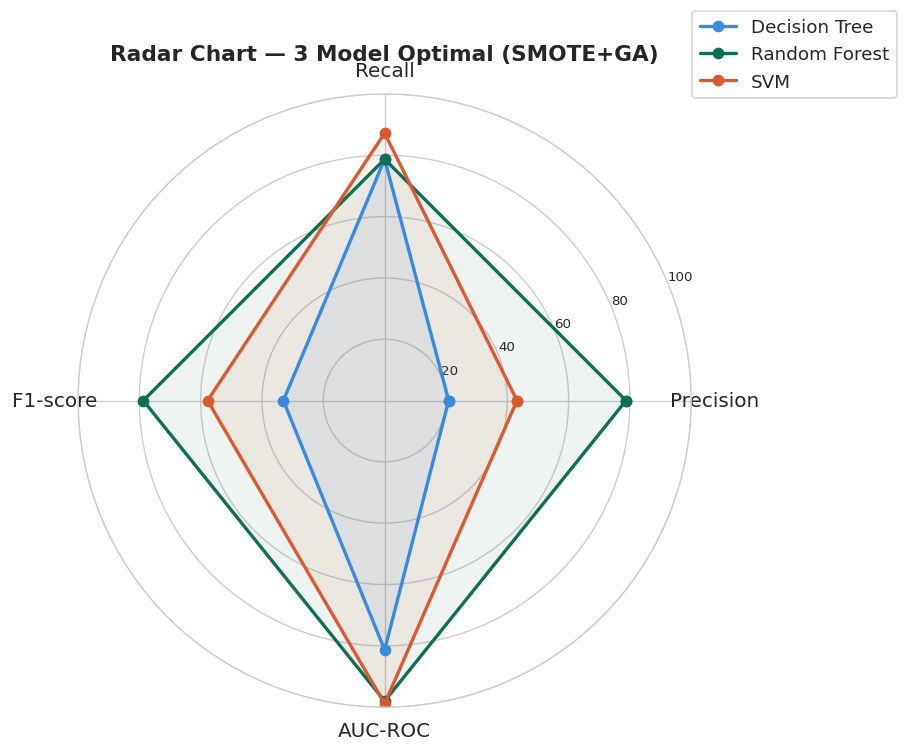

In [29]:
# ── Radar chart — perbandingan 3 model optimal ───────────
from matplotlib.patches import FancyArrowPatch

categories = ['Precision', 'Recall', 'F1-score', 'AUC-ROC']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

for ms, mf, color in zip(models_short, models_full, PALETTE.values()):
    row = df_results[df_results['Eksperimen'] == f'{ms} | SMOTE | GA'].iloc[0]
    values = [row['Precision (%)'], row['Recall (%)'],
              row['F1-score (%)'], row['AUC-ROC (%)']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=mf, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)
ax.set_title('Radar Chart — 3 Model Optimal (SMOTE+GA)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('11_radar_chart.png', bbox_inches='tight')
plt.show()


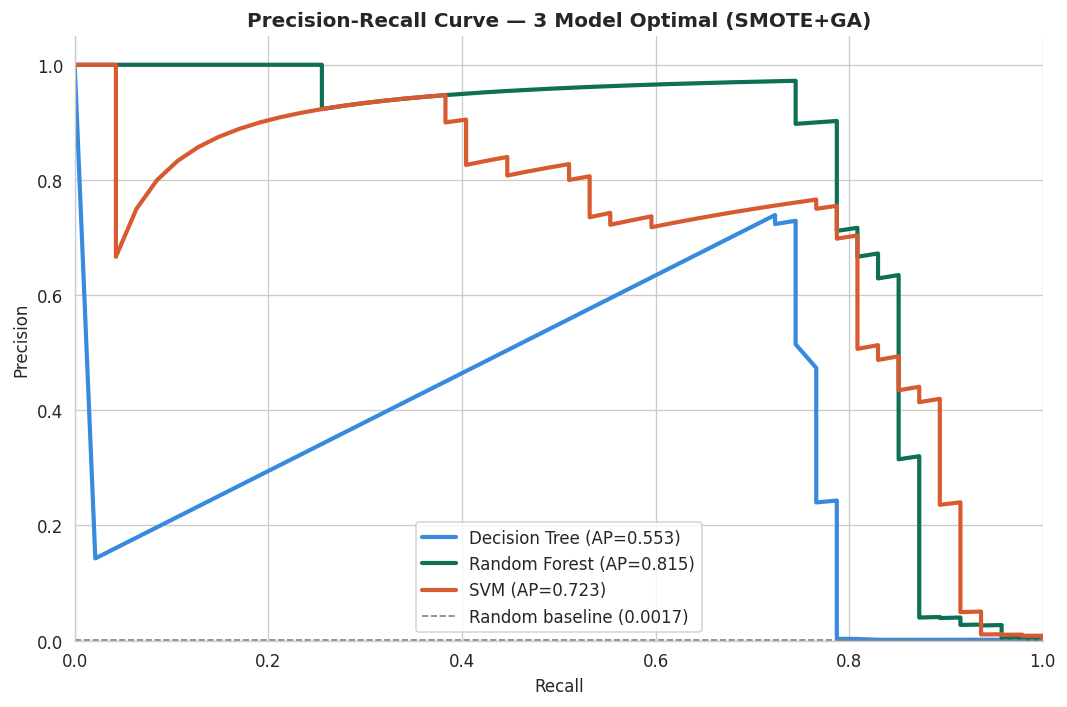

In [30]:
# ── Precision-Recall Curve (lebih informatif untuk imbalanced) ──
fig, ax = plt.subplots(figsize=(9, 6))

for ms, mf, color in zip(models_short, models_full, PALETTE.values()):
    r = next(res for res in results if res['name'] == f'{ms} | SMOTE | GA')
    if r['y_prob'] is not None:
        prec, rec, _ = precision_recall_curve(y_te, r['y_prob'])
        ap = average_precision_score(y_te, r['y_prob'])
        ax.plot(rec, prec, linewidth=2.5, label=f'{mf} (AP={ap:.3f})', color=color)

# Baseline (random)
baseline_pr = y_te.sum() / len(y_te)
ax.axhline(baseline_pr, color='gray', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline_pr:.4f})')

ax.set_title('Precision-Recall Curve — 3 Model Optimal (SMOTE+GA)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('12_precision_recall_curve.png', bbox_inches='tight')
plt.show()


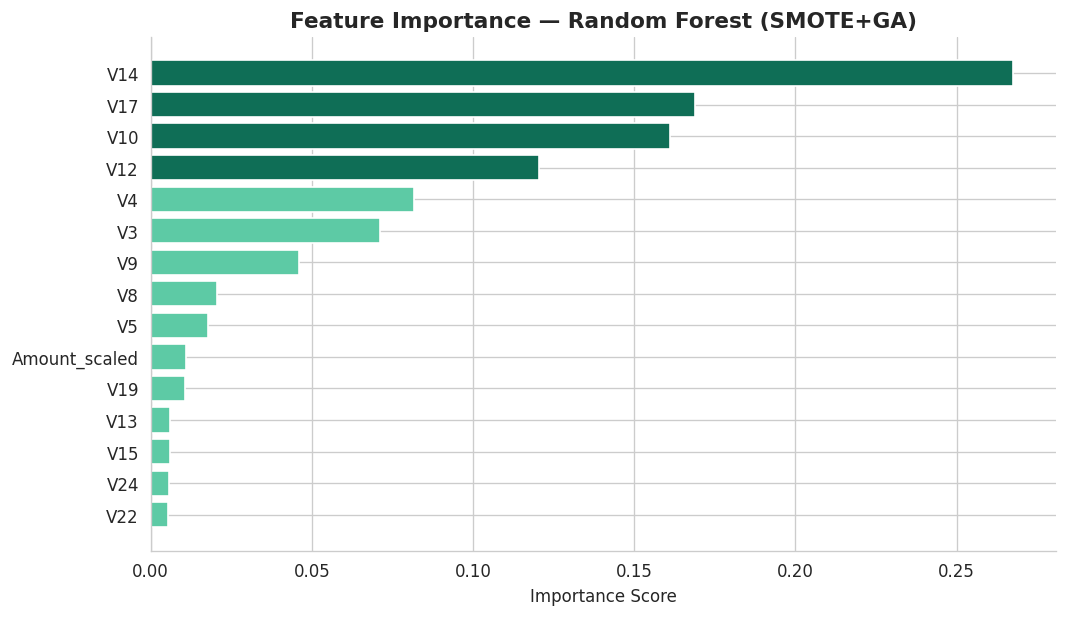

In [31]:
# ── Feature Importance — Random Forest optimal ────────────
rf_opt_model = next(r['model'] for r in results if r['name'] == 'RF | SMOTE | GA')
importances  = rf_opt_model.feature_importances_
feat_names_ga = X_train.columns[ga.best_features_].tolist()

importance_df = pd.DataFrame({
    'Feature': feat_names_ga,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(feat_names_ga) * 0.35)))
colors_imp = ['#0F6E56' if v > importance_df['Importance'].quantile(0.75) else '#5DCAA5'
              for v in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance — Random Forest (SMOTE+GA)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('13_feature_importance.png', bbox_inches='tight')
plt.show()


## 7. Simpan Model Terbaik

Model terbaik akan disimpan bersama scaler dan daftar fitur terpilih agar bisa langsung dipakai di aplikasi Flask.


In [32]:
# ── Tentukan model terbaik ────────────────────────────────
# Prioritas utama adalah Recall tertinggi, jika seri pilih F1-score tertinggi
best_exp_name = df_results.sort_values(by=['Recall (%)', 'F1-score (%)'], ascending=[False, False]).iloc[0]['Eksperimen']
best_result   = next(r for r in results if r['name'] == best_exp_name)

print("=" * 60)
print("MODEL TERBAIK")
print("=" * 60)
print(f"Nama            : {best_exp_name}")
print(f"Precision       : {best_result['precision']:.2f}%")
print(f"Recall          : {best_result['recall']:.2f}%")
print(f"F1-score        : {best_result['f1']:.2f}%")
print(f"AUC-ROC         : {best_result['auc_roc']:.2f}%")
print(f"Fraud terdeteksi: {best_result['tp']}/{best_result['tp']+best_result['fn']}")
print(f"Fraud lolos     : {best_result['fn']}")


MODEL TERBAIK
Nama            : SVM | SMOTE | GA
Precision       : 43.16%
Recall          : 87.23%
F1-score        : 57.75%
AUC-ROC         : 98.86%
Fraud terdeteksi: 41/47
Fraud lolos     : 6


In [33]:
# ── Simpan semua artefak ──────────────────────────────────
import os

os.makedirs('saved_models', exist_ok=True)

# 1. Model terbaik
joblib.dump(best_result['model'], 'saved_models/best_model.pkl')
print("✅ Model terbaik disimpan: saved_models/best_model.pkl")

# 2. Scaler (Amount & Time sudah di-scale di df)
joblib.dump(scaler_amount, 'saved_models/scaler_amount.pkl')
joblib.dump(scaler_time,   'saved_models/scaler_time.pkl')
print("✅ Scaler Amount disimpan : saved_models/scaler_amount.pkl")
print("✅ Scaler Time disimpan   : saved_models/scaler_time.pkl")

# 3. Fitur terpilih GA
joblib.dump(ga.best_features_, 'saved_models/selected_features.pkl')
print("✅ Fitur GA disimpan   : saved_models/selected_features.pkl")

# 4. Nama kolom fitur
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'saved_models/feature_names.pkl')
print("✅ Nama fitur disimpan : saved_models/feature_names.pkl")

# 5. Metadata
metadata = {
    'best_experiment'  : best_exp_name,
    'f1_score'         : best_result['f1'],
    'recall'           : best_result['recall'],
    'precision'        : best_result['precision'],
    'auc_roc'          : best_result['auc_roc'],
    'n_features_total' : X_train.shape[1],
    'n_features_ga'    : len(ga.best_features_),
    'selected_features': feature_names,
    'ga_features_idx'  : ga.best_features_.tolist(),
    'ga_feature_names' : [feature_names[i] for i in ga.best_features_],
    'smote_applied'    : 'SMOTE' in best_exp_name,
    'ga_applied'       : 'noGA' not in best_exp_name,
}
joblib.dump(metadata, 'saved_models/metadata.pkl')
print("✅ Metadata disimpan   : saved_models/metadata.pkl")

print("\n📁 Isi folder saved_models:")
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / 1024
    print(f"   {f} ({size:.1f} KB)")


✅ Model terbaik disimpan: saved_models/best_model.pkl
✅ Scaler Amount disimpan : saved_models/scaler_amount.pkl
✅ Scaler Time disimpan   : saved_models/scaler_time.pkl
✅ Fitur GA disimpan   : saved_models/selected_features.pkl
✅ Nama fitur disimpan : saved_models/feature_names.pkl
✅ Metadata disimpan   : saved_models/metadata.pkl

📁 Isi folder saved_models:
   feature_names.pkl (0.2 KB)
   scaler_amount.pkl (0.9 KB)
   selected_features.pkl (0.3 KB)
   metadata.pkl (0.6 KB)
   scaler_time.pkl (0.9 KB)
   best_model.pkl (95.9 KB)


In [34]:
# ── Download semua model ke lokal ────────────────────────
import shutil

# Zip semua file model
shutil.make_archive('fraud_detection_models', 'zip', 'saved_models')
print("✅ File ZIP dibuat: fraud_detection_models.zip")

# Download dari Colab
try:
    from google.colab import files
    files.download('fraud_detection_models.zip')
    print("⬇️  Download dimulai...")
except ImportError:
    print("ℹ️  Tidak berjalan di Colab — file tersimpan di folder lokal")


✅ File ZIP dibuat: fraud_detection_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download dimulai...


## 8. Verifikasi Model — Simulasi Prediksi

In [35]:
# ── Load model & coba prediksi ───────────────────────────
loaded_model    = joblib.load('saved_models/best_model.pkl')
loaded_features = joblib.load('saved_models/selected_features.pkl')
loaded_metadata = joblib.load('saved_models/metadata.pkl')

print("Model berhasil di-load!")
print(f"Tipe model : {type(loaded_model).__name__}")
print(f"Fitur GA   : {len(loaded_features)} fitur")
print()

# Ambil 5 contoh dari test set
sample_normal = X_test.values[y_te == 0][:3]
sample_fraud  = X_test.values[y_te == 1][:2]
samples       = np.vstack([sample_normal, sample_fraud])
true_labels   = ['Normal', 'Normal', 'Normal', 'Fraud', 'Fraud']

# Determine which features to use for prediction based on the best model's configuration
if loaded_metadata['ga_applied']:
    print("Menggunakan fitur yang dipilih oleh GA untuk prediksi.")
    X_predict = samples[:, loaded_features]
else:
    print("Menggunakan semua fitur untuk prediksi (GA tidak diterapkan pada model terbaik).")
    X_predict = samples

preds      = loaded_model.predict(X_predict)
probs      = loaded_model.predict_proba(X_predict)[:, 1]

print("=" * 55)
print("SIMULASI PREDIKSI (5 sampel test set)")
print("=" * 55)
print(f"{'#':<4} {'Aktual':<10} {'Prediksi':<12} {'Prob Fraud':<12} {'Status'}")
print("-" * 55)
for i, (true, pred, prob) in enumerate(zip(true_labels, preds, probs)):
    pred_label = 'Fraud' if pred == 1 else 'Normal'
    status = '✅ BENAR' if true == pred_label else '❌ SALAH'
    print(f"{i+1:<4} {true:<10} {pred_label:<12} {prob:.4f}       {status}")

Model berhasil di-load!
Tipe model : SVC
Fitur GA   : 15 fitur

Menggunakan fitur yang dipilih oleh GA untuk prediksi.
SIMULASI PREDIKSI (5 sampel test set)
#    Aktual     Prediksi     Prob Fraud   Status
-------------------------------------------------------
1    Normal     Normal       0.0271       ✅ BENAR
2    Normal     Normal       0.0113       ✅ BENAR
3    Normal     Normal       0.0136       ✅ BENAR
4    Fraud      Fraud        1.0000       ✅ BENAR
5    Fraud      Fraud        1.0000       ✅ BENAR


In [36]:
# ── Ringkasan akhir ───────────────────────────────────────
print("=" * 65)
print("RINGKASAN PROJECT — DETEKSI FRAUD KARTU KREDIT")
print("=" * 65)
print()
print(f"Dataset         : {len(df):,} transaksi")
print(f"Proporsi fraud  : {(y==1).sum()} dari {len(y):,} ({(y==1).mean()*100:.3f}%)")
print()
print("Teknik yang digunakan:")
print(f"  • SMOTE       : menyeimbangkan kelas dari rasio 1:{int((y==0).sum()/(y==1).sum())} menjadi 1:1")
print(f"  • Genetic Alg : memilih {len(ga.best_features_)} dari {X_train.shape[1]} fitur secara optimal")
print(f"  • 3 Model     : Decision Tree,  Forest, SVM")
print(f"  • 12 Eksp.    : 3 model × 4 kondisi (±SMOTE ×±GA)")
print()
print("Model Terbaik:")
print(f"  Nama      : {best_exp_name}")
print(f"  Precision : {best_result['precision']:.2f}%")
print(f"  Recall    : {best_result['recall']:.2f}%  ← fraud yg berhasil ditangkap")
print(f"  F1-score  : {best_result['f1']:.2f}%")
print(f"  AUC-ROC   : {best_result['auc_roc']:.2f}%")
print()
print("File tersimpan di fraud_detection_models.zip:")
print("  • best_model.pkl         → model siap deploy ke Flask")
print("  • scaler.pkl             → normalisasi input baru")
print("  • selected_features.pkl  → indeks fitur GA")
print("  • feature_names.pkl      → nama semua fitur")
print("  • metadata.pkl           → info lengkap eksperimen")
print()
print("✅ Notebook selesai! Model siap dipakai di aplikasi web Flask.")


RINGKASAN PROJECT — DETEKSI FRAUD KARTU KREDIT

Dataset         : 283,726 transaksi
Proporsi fraud  : 473 dari 283,726 (0.167%)

Teknik yang digunakan:
  • SMOTE       : menyeimbangkan kelas dari rasio 1:598 menjadi 1:1
  • Genetic Alg : memilih 15 dari 30 fitur secara optimal
  • 3 Model     : Decision Tree,  Forest, SVM
  • 12 Eksp.    : 3 model × 4 kondisi (±SMOTE ×±GA)

Model Terbaik:
  Nama      : SVM | SMOTE | GA
  Precision : 43.16%
  Recall    : 87.23%  ← fraud yg berhasil ditangkap
  F1-score  : 57.75%
  AUC-ROC   : 98.86%

File tersimpan di fraud_detection_models.zip:
  • best_model.pkl         → model siap deploy ke Flask
  • scaler.pkl             → normalisasi input baru
  • selected_features.pkl  → indeks fitur GA
  • feature_names.pkl      → nama semua fitur
  • metadata.pkl           → info lengkap eksperimen

✅ Notebook selesai! Model siap dipakai di aplikasi web Flask.
